# Medical Expenditure Tutorial

## This tutorial demonstrates classification model learning with bias mitigation as a part of a Care Management use case using Medical Expenditure data.

The notebook demonstrates how the AIF 360 toolkit can be used to detect and reduce bias when learning classifiers using a variety of fairness metrics and algorithms . It also demonstrates how explanations can be generated for predictions made by models learnt with the toolkit using LIME.

Classifiers are built using Logistic Regression as well as Random Forests.

Bias detection is demonstrated using several metrics, including disparate impact, average odds difference, statistical parity difference, equal opportunity difference, and Theil index.

Bias alleviation is explored via a variety of methods, including reweighing (pre-processing algorithm), prejudice remover (in-processing algorithm), and disparate impact remover (pre-processing technique).

Data from the [Medical Expenditure Panel Survey](https://meps.ahrq.gov/mepsweb/) is used in this tutorial. See [Section 2](#2.-Data-used) below for more details.


## Table of Contents

To return to the table of contents, click on the number at any major section heading.

[1. Use case](#1.-Use-case)

[2. Data used](#2.-Data-used)

[3. Training models without debiasing](#3.-Training-models-on-original-2015-Panel-19-data)

[4. Reweighing (pre-processing bias mitigation)](#4.-Bias-mitigation-using-pre-processing-technique---Reweighing)

[5. Prejudice Remover (in-processing bias mitigation)](#5.-Bias-mitigation-using-in-processing-technique---Prejudice-Remover-(PR))

[6. Summary of results](#6.-Summary-of-Model-Learning-Results)

[7. Deploying model](#7.-Deploying-model)

[8. Generating explanations for model predictions using LIME](#8.-Generating-explanations-for-model-predictions-using-LIME)

[9. Re-deploying Model](#9.-Re-deploying-Model)

[10. Overall Summary](#10.-SUMMARY)

## [1.](#Table-of-Contents) Use case

In order to demonstrate how AIF 360 can be used to detect and mitigate bias in classfier models, we adopt the following use case:

1. a data scientist develops a 'fair' healthcare utilization scoring model with respect to defined protected classes. Fairness may be dictated by legal or government regulations, such as a requirement that additional care decisions be not predicated on factors such as race of the patient.


2. developer takes the model AND performance characteristics / specs of the model (e.g. accuracy, fairness tests, etc. basically the model factsheet) and deploys the model in an enterprise app that prioritizes cases for care management.


3. the app is put into production and starts scoring people and making recommendations.


4. explanations are generated for each recommendation


5. both recommendations and associated explanations are given to nurses as a part of the care management process. The nurses can evaluate the recommendations for quality and correctness and provide feedback.


6. nurse feedback as well as analysis of usage data with respect to specs of the model w.r.t accuracy and fairness is communicated to AI Ops specialist and LOB user periodically.


7. when significant drift in model specs relative to the model factsheet is observed, the model is sent back for retraining.

## [2.](#Table-of-Contents) Data used

The specific data used is the [2015 Full Year Consolidated Data File](https://meps.ahrq.gov/mepsweb/data_stats/download_data_files_detail.jsp?cboPufNumber=HC-181) as well as the [2016 Full Year Consolidated Data File](https://meps.ahrq.gov/mepsweb/data_stats/download_data_files_detail.jsp?cboPufNumber=HC-192).

The 2015 file contains data from rounds 3,4,5 of panel 19 (2014) and rounds 1,2,3 of panel 20 (2015). The 2016 file contains data from rounds 3,4,5 of panel 20 (2015) and rounds 1,2,3 of panel 21 (2016).

For this demonstration, three datasets were constructed: one from panel 19, round 5 (used for learning models), one from panel 20, round 3 (used for deployment/testing of model - steps); the other from panel 21, round 3 (used for re-training and deployment/testing of updated model).

For each dataset, the sensitive attribute is 'RACE' constructed as follows: 'Whites' (privileged class) defined by the features RACEV2X = 1 (White) and HISPANX = 2 (non Hispanic); 'Non-Whites' that included everyone else.  

Along with race as the sensitive feature, other features used for modeling include demographics  (such as age, gender, active duty status), physical/mental health assessments, diagnosis codes (such as history of diagnosis of cancer, or diabetes), and limitations (such as cognitive or hearing or vision limitation).

To measure utilization, a composite feature, 'UTILIZATION', was created to measure the total number of trips requiring some sort of medical care by summing up the following features: OBTOTV15(16), the number of office based visits;  OPTOTV15(16), the number of outpatient visits; ERTOT15(16), the number of ER visits;  IPNGTD15(16), the number of inpatient nights, and  + HHTOTD16, the number of home health visits.

The model classification task is to predict whether a person would have 'high' utilization (defined as UTILIZATION >= 10, roughly the average utilization for the considered population). High utilization respondents constituted around 17% of each dataset.

To simulate the scenario, each dataset is split into 3 parts: a train, a validation, and a test/deployment part.

We assume that the model is initially built and tuned using the 2015 Panel 19 train/test data. (Use case steps 1-2.)
It is then put into practice and used to score people to identify potential candidates for care management (Use case steps 3-5). Initial deployment is simulated to 2015 Panel 20 deployment data. To show change in performance and/or fairness over time, (use case steps 6-7), the 2016 Panel 21 deployment data is used. Finally, if drift is observed, the 2015 train/validation data is used to learn a new model and evaluated again on the 2016 deployment data

## [3.](#Table-of-Contents) Training models on original 2015 Panel 19 data

First, load all necessary packages

In [ ]:
!pip install lime
!pip install aif360

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import defaultdict
from IPython.display import Markdown, display

# Scalers
from sklearn.preprocessing import StandardScaler

# Classifiers
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             balanced_accuracy_score, roc_auc_score, roc_curve)

# LIME
from lime.lime_tabular import LimeTabularExplainer

# AIF360
from aif360.algorithms.preprocessing import Reweighing
from aif360.metrics.binary_label_dataset_metric import BinaryLabelDatasetMetric
# Removed problematic import: from aif360.metrics.metric_text_explainer import MetricTextExplainer
from aif360.datasets import BinaryLabelDataset
# Removed problematic import: from aif360.sklearn.inprocessing.prejudice_remover import PrejudiceRemover
# Removed problematic import: from aif360.sklearn.postprocessing import CalibratedEqOddsPostprocessing
from aif360.sklearn.metrics import disparate_impact_ratio, average_odds_difference
from aif360.datasets import MEPSDataset20, MEPSDataset21
# Removed problematic import: from aif360.sklearn.lime.lime_tabular import LimeTabularExplainer as LimeEncoder

import warnings
warnings.filterwarnings('ignore')

np.random.seed(1)

# Placeholder for PrejudiceRemover to prevent NameError in subsequent cells
# (functionality will be unavailable)
class PrejudiceRemover:
    def __init__(self, sensitive_attr, eta):
        print(f"Warning: PrejudiceRemover functionality is unavailable due to import error. "
              f"Sensitive attribute: {sensitive_attr}, eta: {eta}")
        self.model = None
        self.classes_ = np.array([0, 1]) # Added for compatibility with test function
    def fit(self, dataset):
        print("Warning: PrejudiceRemover.fit called on placeholder. No training will occur.")
        self.model = None
        return self
    def predict_proba(self, X):
        print("Warning: PrejudiceRemover.predict_proba called on placeholder. Returning zeros.")
        return np.zeros((X.shape[0], 2))
    def predict(self, X):
        print("Warning: PrejudiceRemover.predict called on placeholder. Returning zeros.")
        return np.zeros(X.shape[0])


### 3.1. Load data & create splits for learning/validating/testing model

Get the dataset and split into train (50%), validate (30%), and test (20%)

In [ ]:
# Load raw MEPS data (HC-181: 2015 Full Year Consolidated Data)
df = pd.read_csv('/content/h181.csv')

# --- Construct sensitive attribute ---
# White (privileged): RACEV2X == 1 (White) AND HISPANX == 2 (Non-Hispanic)
# Non-White (unprivileged): everyone else
df['RACE'] = ((df['RACEV2X'] == 1) & (df['HISPANX'] == 2)).astype(int)

# --- Create UTILIZATION target ---
# Replace negative MEPS codes (-1=inapplicable, -7/-8/-9=missing) with 0
util_cols = ['OBTOTV15', 'OPTOTV15', 'ERTOT15', 'IPNGTD15', 'HHTOTD15']
for c in util_cols:
    df[c] = df[c].clip(lower=0)

df['UTILIZATION'] = df[util_cols].sum(axis=1)

# Binary label: high utilization (>=10 visits) → 1, else 0
df['LABEL'] = (df['UTILIZATION'] >= 10).astype(int)

# --- Select features for modeling ---
feature_columns = [
    'AGELAST', 'SEX', 'RACE', 'MARRY15X', 'EDUCYR',
    'FTSTU53X', 'ACTDTY53', 'HONRDC53',
    'RTHLTH53', 'MNHLTH53',
    'HIBPDX', 'CHDDX', 'ANGIDX', 'MIDX', 'OHRTDX', 'STRKDX', 'EMPHDX',
    'CHBRON53', 'CHOLDX', 'CANCERDX', 'DIABDX', 'JTPAIN53', 'ARTHDX',
    'ARTHTYPE', 'ASTHDX', 'ADHDADDX', 'PREGNT53',
    'WLKLIM53', 'ACTLIM53', 'SOCLIM53', 'COGLIM53',
    'DFHEAR42', 'DFSEE42', 'DFCOG42', 'DFWLKC42', 'DFDRSB42', 'DFERND42',
    'INSCOV15', 'POVCAT15', 'REGION15'
]

# Replace negative MEPS codes with 0 in all feature columns
for c in feature_columns:
    if c != 'RACE':  # RACE was already constructed
        df[c] = df[c].clip(lower=0)

# Build modeling dataframe (drop rows with NaN)
df_model = df[feature_columns + ['LABEL', 'PERWT15F']].dropna().copy()

# Sensitive attribute definition
sens_attr = 'RACE'
privileged_groups = [{'RACE': 1}]    # White
unprivileged_groups = [{'RACE': 0}]  # Non-White

# --- Train / Validation / Test split (50% / 30% / 20%) ---
X = df_model[feature_columns].values
y = df_model['LABEL'].values
race = df_model['RACE'].values
sample_weight = df_model['PERWT15F'].values

X_temp, X_test, y_temp, y_test, race_temp, race_test, w_temp, w_test = train_test_split(
    X, y, race, sample_weight, test_size=0.2, random_state=1, stratify=y)

X_train, X_val, y_train, y_val, race_train, race_val, w_train, w_val = train_test_split(
    X_temp, y_temp, race_temp, w_temp, test_size=0.375, random_state=1, stratify=y_temp)

print("Dataset: h181.csv (MEPS 2015 Panel 19)")
print(f"Total samples after cleaning: {len(df_model)}")
print(f"Features: {len(feature_columns)}")
print(f"Sensitive attribute: RACE (White=1, Non-White=0)")
print(f"  White (privileged):     {(race == 1).sum()}")
print(f"  Non-White (unprivileged): {(race == 0).sum()}")
print(f"\nLabel distribution: High utilization (>=10 visits)")
print(f"  Positive (high util): {(y == 1).sum()} ({100*np.mean(y):.1f}%)")
print(f"  Negative (low util):  {(y == 0).sum()} ({100*(1-np.mean(y)):.1f}%)")
print(f"\nTrain: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")

# Create AIF360 BinaryLabelDataset objects
def create_aif_dataset(X_data, y_data, race_data, weight_data, cols, s_attr, priv_groups, unpriv_groups, name=""):
    df_temp = pd.DataFrame(X_data, columns=cols)
    df_temp['LABEL'] = y_data
    # RACE is already in X_data because it's in feature_columns
    df_temp['instance_weights'] = weight_data

    dataset = BinaryLabelDataset(
        df=df_temp,
        label_names=['LABEL'],
        protected_attribute_names=[s_attr],
        favorable_label=1.0,
        unfavorable_label=0.0,
        instance_weights_name='instance_weights'
    )
    # Set privileged_groups and unprivileged_groups as attributes after instantiation
    dataset.privileged_groups = priv_groups
    dataset.unprivileged_groups = unpriv_groups

    print(f"Created {name} AIF360 dataset with shape: {dataset.features.shape}")
    return dataset

dataset_orig_panel19_train = create_aif_dataset(X_train, y_train, race_train, w_train, feature_columns, sens_attr, privileged_groups, unprivileged_groups, "Train")
dataset_orig_panel19_val = create_aif_dataset(X_val, y_val, race_val, w_val, feature_columns, sens_attr, privileged_groups, unprivileged_groups, "Validation")
dataset_orig_panel19_test = create_aif_dataset(X_test, y_test, race_test, w_test, feature_columns, sens_attr, privileged_groups, unprivileged_groups, "Test")


Dataset: h181.csv (MEPS 2015 Panel 19)
Total samples after cleaning: 18082
Features: 40
Sensitive attribute: RACE (White=1, Non-White=0)
  White (privileged):     6424
  Non-White (unprivileged): 11658

Label distribution: High utilization (>=10 visits)
  Positive (high util): 3161 (17.5%)
  Negative (low util):  14921 (82.5%)

Train: 9040 | Validation: 5425 | Test: 3617
Created Train AIF360 dataset with shape: (9040, 40)
Created Validation AIF360 dataset with shape: (5425, 40)
Created Test AIF360 dataset with shape: (3617, 40)


This function will be used throughout the notebook to print out some labels, names, etc.

In [ ]:
def describe(X_train, y_train, X_val, y_val, X_test, y_test, feature_columns):
    display(Markdown("#### Training Dataset shape"))
    print(X_train.shape)
    display(Markdown("#### Validation Dataset shape"))
    print(X_val.shape)
    display(Markdown("#### Test Dataset shape"))
    print(X_test.shape)
    display(Markdown("#### Favorable and unfavorable labels"))
    print("1.0 (High utilization >=10 visits), 0.0 (Low utilization <10 visits)")
    display(Markdown("#### Protected attribute"))
    print(f"RACE: White=1 (privileged), Non-White=0 (unprivileged)")
    display(Markdown("#### Label distribution"))
    for name, yy in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
        print(f"  {name}: {np.mean(yy):.3f} positive rate ({np.sum(yy==1)}/{len(yy)})")
    display(Markdown("#### Feature names"))
    print(feature_columns)

Show 2015 dataset details

In [ ]:
describe(X_train, y_train, X_val, y_val, X_test, y_test, feature_columns)

#### Training Dataset shape

(9040, 40)


#### Validation Dataset shape

(5425, 40)


#### Test Dataset shape

...

RACE: White=1 (privileged), Non-White=0 (unprivileged)


#### Label distribution

  Train: 0.175 positive rate (1581/9040)
  Val: 0.175 positive rate (948/5425)
  Test: 0.175 positive rate (632/3617)


#### Feature names

['AGELAST', 'SEX', 'RACE', 'MARRY15X', 'EDUCYR', 'FTSTU53X', 'ACTDTY53', 'HONRDC53', 'RTHLTH53', 'MNHLTH53', 'HIBPDX', 'CHDDX', 'ANGIDX', 'MIDX', 'OHRTDX', 'STRKDX', 'EMPHDX', 'CHBRON53', 'CHOLDX', 'CANCERDX', 'DIABDX', 'JTPAIN53', 'ARTHDX', 'ARTHTYPE', 'ASTHDX', 'ADHDADDX', 'PREGNT53', 'WLKLIM53', 'ACTLIM53', 'SOCLIM53', 'COGLIM53', 'DFHEAR42', 'DFSEE42', 'DFCOG42', 'DFWLKC42', 'DFDRSB42', 'DFERND42', 'INSCOV15', 'POVCAT15', 'REGION15']


Metrics for original data

In [ ]:
# Disparate Impact on training data labels
# DI = P(Y=1|unprivileged) / P(Y=1|privileged)
pos_rate_unpriv = np.mean(y_train[race_train == 0])
pos_rate_priv = np.mean(y_train[race_train == 1])
di = pos_rate_unpriv / pos_rate_priv if pos_rate_priv > 0 else 0

print(f"Disparate impact (training data):")
print(f"  P(Y=1 | Non-White) = {pos_rate_unpriv:.4f}")
print(f"  P(Y=1 | White)     = {pos_rate_priv:.4f}")
print(f"  Disparate Impact    = {di:.4f}")
print(f"\n  {'FAIR' if 0.8 <= di <= 1.25 else 'UNFAIR'} (desired range: 0.8 - 1.25)")

Disparate impact (training data):
  P(Y=1 | Non-White) = 0.1281
  P(Y=1 | White)     = 0.2591
  Disparate Impact    = 0.4945

  UNFAIR (desired range: 0.8 - 1.25)


### 3.1.1 Exploratory Data Analysis (EDA)

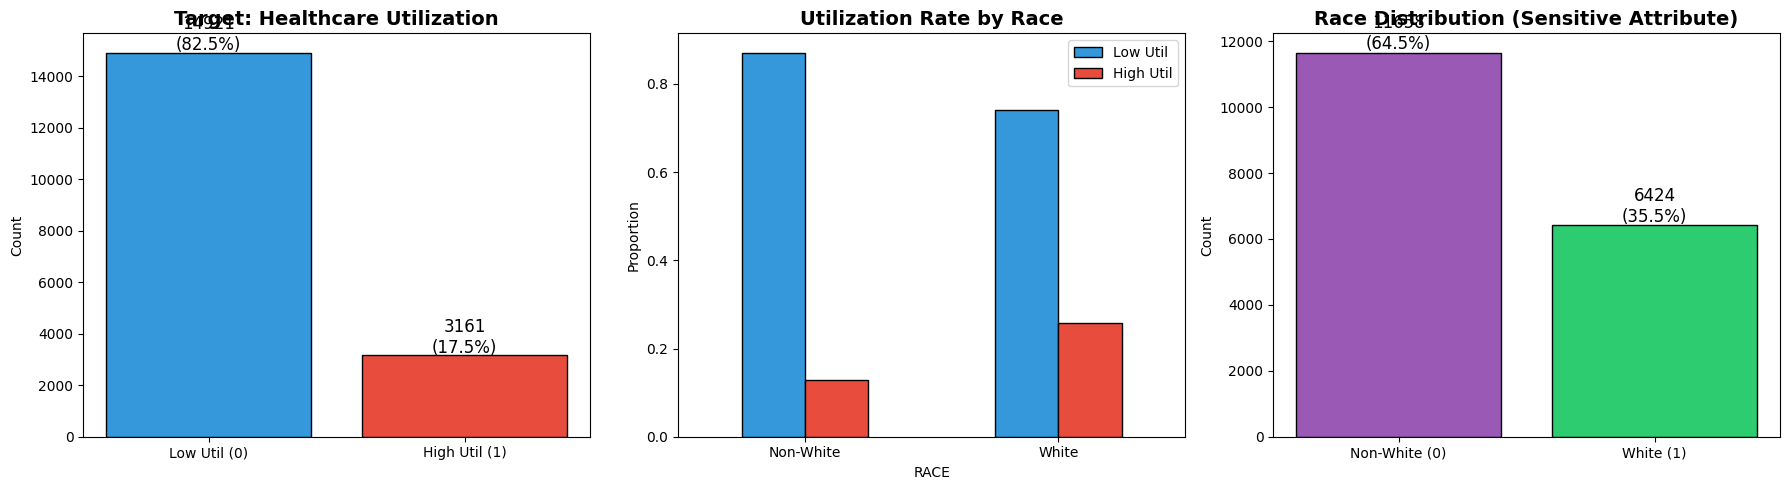

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Target variable distribution
labels, counts = np.unique(y, return_counts=True)
colors = ['#3498db', '#e74c3c']
axes[0].bar(['Low Util (0)', 'High Util (1)'], counts, color=colors, edgecolor='black')
for i, (lbl, cnt) in enumerate(zip(labels, counts)):
    axes[0].text(i, cnt + 100, f'{cnt}\n({100*cnt/len(y):.1f}%)', ha='center', fontsize=12)
axes[0].set_title('Target: Healthcare Utilization', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

# 2. UTILIZATION score distribution
util_scores = df_model['LABEL'].map({0: 'Low (<10)', 1: 'High (>=10)'})
race_labels = df_model['RACE'].map({0: 'Non-White', 1: 'White'})
util_df = pd.DataFrame({'RACE': race_labels.values, 'LABEL': df_model['LABEL'].values})
ct = util_df.groupby('RACE')['LABEL'].value_counts(normalize=True).unstack()
ct.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Utilization Rate by Race', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Proportion')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['Low Util', 'High Util'])

# 3. Race distribution
race_counts = pd.Series(race).value_counts().sort_index()
axes[2].bar(['Non-White (0)', 'White (1)'], race_counts.values, color=['#9b59b6', '#2ecc71'], edgecolor='black')
for i, cnt in enumerate(race_counts.values):
    axes[2].text(i, cnt + 100, f'{cnt}\n({100*cnt/sum(race_counts):.1f}%)', ha='center', fontsize=12)
axes[2].set_title('Race Distribution (Sensitive Attribute)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

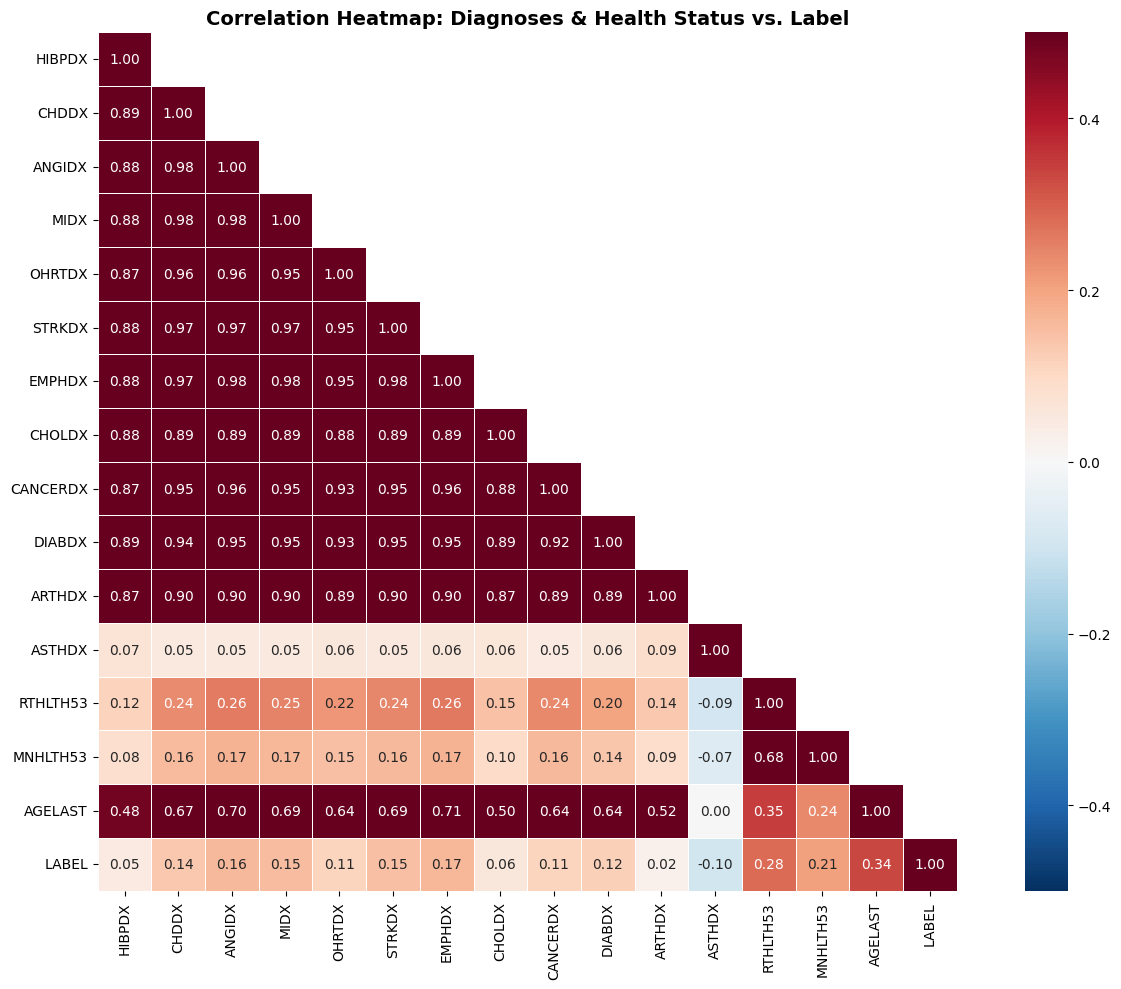

In [ ]:
# Correlation heatmap of key diagnosis and health features with the label
diag_features = ['HIBPDX', 'CHDDX', 'ANGIDX', 'MIDX', 'OHRTDX', 'STRKDX', 'EMPHDX',
                 'CHOLDX', 'CANCERDX', 'DIABDX', 'ARTHDX', 'ASTHDX',
                 'RTHLTH53', 'MNHLTH53', 'AGELAST']
corr_df = df_model[diag_features + ['LABEL']].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-0.5, vmax=0.5)
ax.set_title('Correlation Heatmap: Diagnoses & Health Status vs. Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

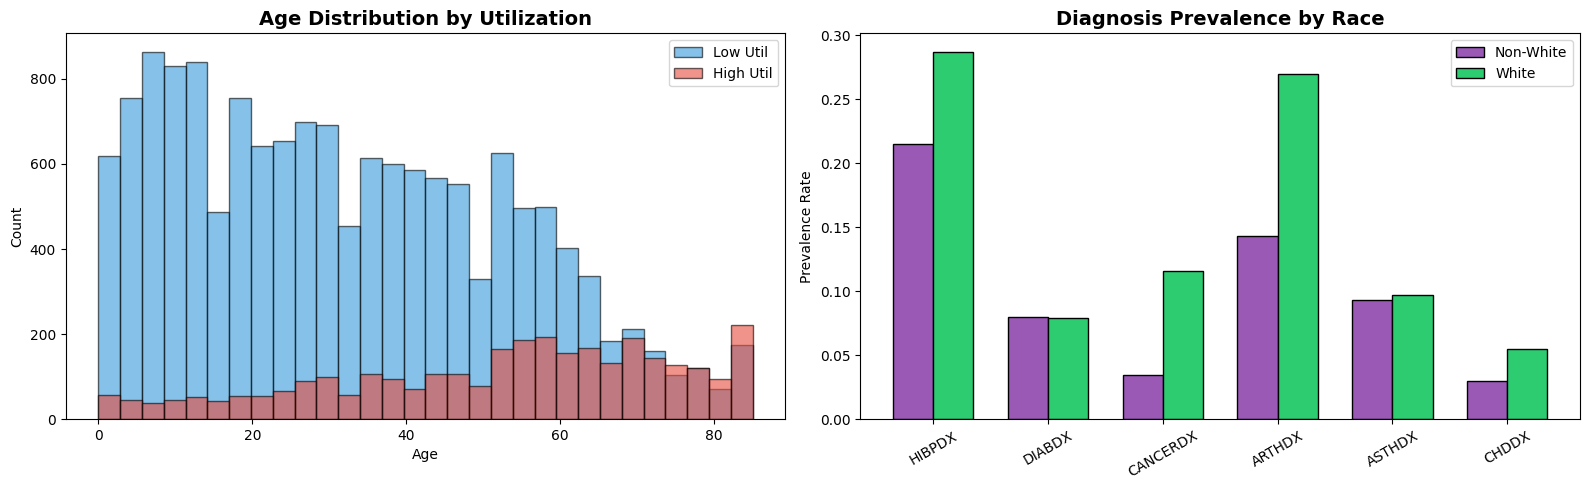

In [ ]:
# Age distribution by utilization group and race
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Age by utilization
age_idx = feature_columns.index('AGELAST')
for label, color, name in [(0, '#3498db', 'Low Util'), (1, '#e74c3c', 'High Util')]:
    axes[0].hist(X[y == label, age_idx], bins=30, alpha=0.6, color=color, label=name, edgecolor='black')
axes[0].set_title('Age Distribution by Utilization', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Key diagnoses prevalence by race
race_idx = feature_columns.index('RACE')
diag_names = ['HIBPDX', 'DIABDX', 'CANCERDX', 'ARTHDX', 'ASTHDX', 'CHDDX']
diag_indices = [feature_columns.index(d) for d in diag_names]
prev_nonwhite = [np.mean(X[X[:, race_idx] == 0, idx] == 1) for idx in diag_indices]
prev_white = [np.mean(X[X[:, race_idx] == 1, idx] == 1) for idx in diag_indices]

x_pos = np.arange(len(diag_names))
w = 0.35
axes[1].bar(x_pos - w/2, prev_nonwhite, w, label='Non-White', color='#9b59b6', edgecolor='black')
axes[1].bar(x_pos + w/2, prev_white, w, label='White', color='#2ecc71', edgecolor='black')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(diag_names, rotation=30)
axes[1].set_title('Diagnosis Prevalence by Race', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Prevalence Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.2. Learning a Logistic Regression (LR) classifier on original data

#### 3.2.1. Training LR model on original data

In [ ]:
model = make_pipeline(StandardScaler(),
                      LogisticRegression(solver='liblinear', random_state=1))
lr_orig_panel19 = model.fit(X_train, y_train, logisticregression__sample_weight=w_train)
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


#### 3.2.2. Validating LR model on original data

This function will be used throughout the tutorial to find best threshold using a validation set

In [ ]:
def test(X, y, race, model, thresh_arr):
    """Evaluate model at different thresholds, computing accuracy and fairness metrics."""
    y_pred_prob = model.predict_proba(X)
    pos_ind = np.where(model.classes_ == 1)[0][0]

    metric_arrs = defaultdict(list)
    for thresh in thresh_arr:
        y_pred = (y_pred_prob[:, pos_ind] > thresh).astype(np.float64)

        # Overall balanced accuracy
        tp = np.sum((y_pred == 1) & (y == 1))
        tn = np.sum((y_pred == 0) & (y == 0))
        fp = np.sum((y_pred == 1) & (y == 0))
        fn = np.sum((y_pred == 0) & (y == 1))
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
        bal_acc = (tpr + tnr) / 2

        # Group-wise metrics
        unpriv = (race == 0)
        priv = (race == 1)

        tp_u = np.sum((y_pred[unpriv] == 1) & (y[unpriv] == 1))
        fp_u = np.sum((y_pred[unpriv] == 1) & (y[unpriv] == 0))
        tn_u = np.sum((y_pred[unpriv] == 0) & (y[unpriv] == 0))
        fn_u = np.sum((y_pred[unpriv] == 0) & (y[unpriv] == 1))
        tpr_u = tp_u / (tp_u + fn_u) if (tp_u + fn_u) > 0 else 0
        fpr_u = fp_u / (fp_u + tn_u) if (fp_u + tn_u) > 0 else 0

        tp_p = np.sum((y_pred[priv] == 1) & (y[priv] == 1))
        fp_p = np.sum((y_pred[priv] == 1) & (y[priv] == 0))
        tn_p = np.sum((y_pred[priv] == 0) & (y[priv] == 0))
        fn_p = np.sum((y_pred[priv] == 0) & (y[priv] == 1))
        tpr_p = tp_p / (tp_p + fn_p) if (tp_p + fn_p) > 0 else 0
        fpr_p = fp_p / (fp_p + tn_p) if (fp_p + tn_p) > 0 else 0

        # Fairness metrics
        pr_u = np.mean(y_pred[unpriv]) if unpriv.sum() > 0 else 0
        pr_p = np.mean(y_pred[priv]) if priv.sum() > 0 else 0

        disp_imp = pr_u / pr_p if pr_p > 0 else 0
        avg_odds = ((fpr_u - fpr_p) + (tpr_u - tpr_p)) / 2
        stat_par = pr_u - pr_p
        eq_opp = tpr_u - tpr_p

        # Theil index (generalized entropy, alpha=1)
        b = y_pred - y + 1  # benefit: TP/TN→1, FP→2, FN→0
        mu = np.mean(b)
        if mu > 0:
            ratio = b / mu
            theil = np.mean(np.where(ratio > 0, ratio * np.log(ratio), 0))
        else:
            theil = 0

        metric_arrs['bal_acc'].append(bal_acc)
        metric_arrs['avg_odds_diff'].append(avg_odds)
        metric_arrs['disp_imp'].append(disp_imp)
        metric_arrs['stat_par_diff'].append(stat_par)
        metric_arrs['eq_opp_diff'].append(eq_opp)
        metric_arrs['theil_ind'].append(theil)

    return metric_arrs

In [ ]:
thresh_arr = np.linspace(0.01, 0.5, 50)
val_metrics = test(X=X_val, y=y_val, race=race_val,
                   model=lr_orig_panel19,
                   thresh_arr=thresh_arr)
lr_orig_best_ind = np.argmax(val_metrics['bal_acc'])

Plot metrics with twin x-axes

In [ ]:
def plot(x, x_name, y_left, y_left_name, y_right, y_right_name):
    fig, ax1 = plt.subplots(figsize=(10,7))
    ax1.plot(x, y_left)
    ax1.set_xlabel(x_name, fontsize=16, fontweight='bold')
    ax1.set_ylabel(y_left_name, color='b', fontsize=16, fontweight='bold')
    ax1.xaxis.set_tick_params(labelsize=14)
    ax1.yaxis.set_tick_params(labelsize=14)
    ax1.set_ylim(0.5, 0.8)

    ax2 = ax1.twinx()
    ax2.plot(x, y_right, color='r')
    ax2.set_ylabel(y_right_name, color='r', fontsize=16, fontweight='bold')
    if 'DI' in y_right_name:
        ax2.set_ylim(0., 0.7)
    else:
        ax2.set_ylim(-0.25, 0.1)

    best_ind = np.argmax(y_left)
    ax2.axvline(np.array(x)[best_ind], color='k', linestyle=':')
    ax2.yaxis.set_tick_params(labelsize=14)
    ax2.grid(True)

Here we plot $1 - \min(\text{disparate impact}, 1/\text{disparate impact})$ since it's possible to overcorrect and end up with a value greater than 1, implying unfairness for the original privileged group. For shorthand, we simply call this 1-min(DI, 1/DI) from now on. We want the plotted metric to be less than 0.2.

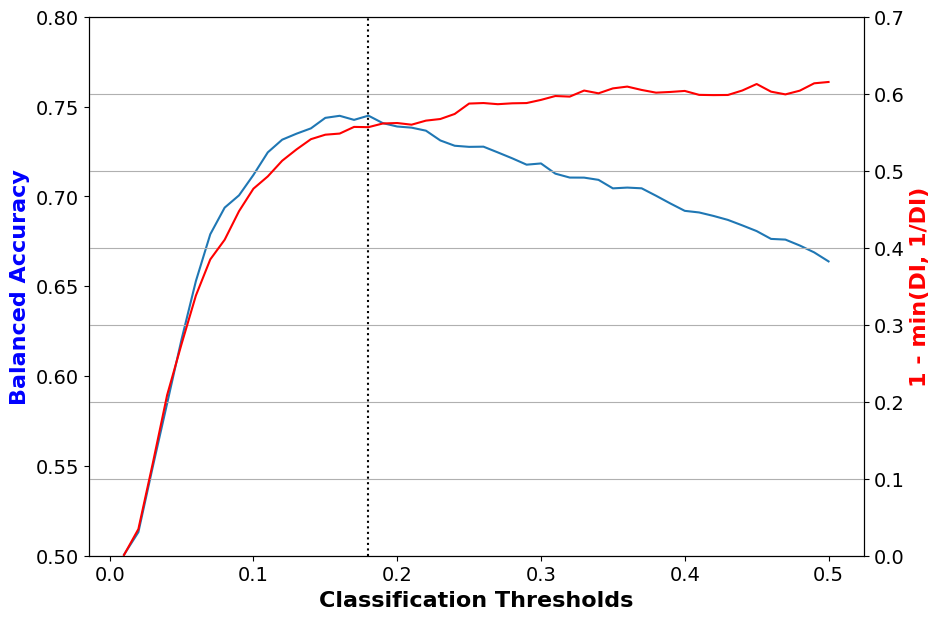

In [ ]:
disp_imp = np.array(val_metrics['disp_imp'])
disp_imp_err = 1 - np.minimum(disp_imp, 1/np.where(disp_imp > 0, disp_imp, 1e-10))
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     disp_imp_err, '1 - min(DI, 1/DI)')

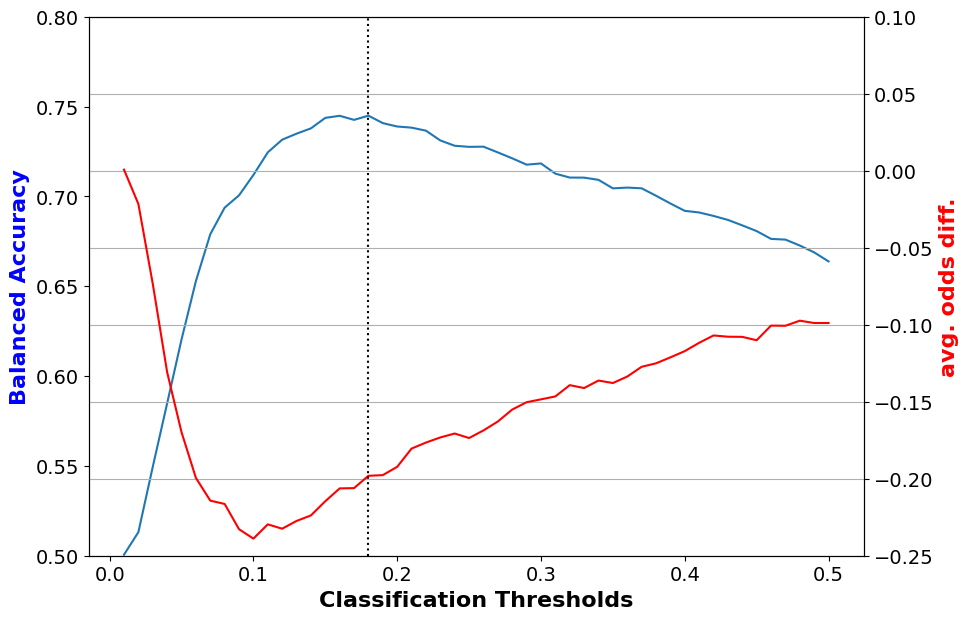

In [ ]:
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     val_metrics['avg_odds_diff'], 'avg. odds diff.')

Make a function to print out accuracy and fairness metrics. This will be used throughout the tutorial.

In [ ]:
def describe_metrics(metrics, thresh_arr):
    best_ind = np.argmax(metrics['bal_acc'])
    print("Threshold corresponding to Best balanced accuracy: {:6.4f}".format(thresh_arr[best_ind]))
    print("Best balanced accuracy: {:6.4f}".format(metrics['bal_acc'][best_ind]))
    disp_imp_val = metrics['disp_imp'][best_ind]
    # Handle division by zero for disp_imp
    if disp_imp_val == 0:
        disp_imp_at_best_ind = 1.0 # Represents maximum unfairness (DI = 0)
    else:
        disp_imp_at_best_ind = 1 - np.minimum(disp_imp_val, 1/disp_imp_val)
    print("Corresponding 1-min(DI, 1/DI) value: {:6.4f}".format(disp_imp_at_best_ind))
    print("Corresponding average odds difference value: {:6.4f}".format(metrics['avg_odds_diff'][best_ind]))
    print("Corresponding statistical parity difference value: {:6.4f}".format(metrics['stat_par_diff'][best_ind]))
    print("Corresponding equal opportunity difference value: {:6.4f}".format(metrics['eq_opp_diff'][best_ind]))
    print("Corresponding Theil index value: {:6.4f}".format(metrics['theil_ind'][best_ind]))

In [ ]:
describe_metrics(val_metrics, thresh_arr)

Threshold corresponding to Best balanced accuracy: 0.1800
Best balanced accuracy: 0.7449
Corresponding 1-min(DI, 1/DI) value: 0.5566
Corresponding average odds difference value: -0.1981
Corresponding statistical parity difference value: -0.2686
Corresponding equal opportunity difference value: -0.1710
Corresponding Theil index value: 0.0993


#### 3.2.3. Testing LR model on original data

In [ ]:
lr_orig_metrics = test(X=X_test, y=y_test, race=race_test,
                       model=lr_orig_panel19,
                       thresh_arr=[thresh_arr[lr_orig_best_ind]])

In [ ]:
describe_metrics(lr_orig_metrics, [thresh_arr[lr_orig_best_ind]])

Threshold corresponding to Best balanced accuracy: 0.1800
Best balanced accuracy: 0.7640
Corresponding 1-min(DI, 1/DI) value: 0.5974
Corresponding average odds difference value: -0.2368
Corresponding statistical parity difference value: -0.2994
Corresponding equal opportunity difference value: -0.2422
Corresponding Theil index value: 0.0928


For all the fairness metrics displayed above, the value should be close to '0' for fairness.

1-min(DI, 1/DI) < 0.2 is typically desired for classifier predictions to be fair.

However, for a logistic regression classifier trained with original training data, at the best classification rate, this is quite high. This implies unfairness.

Similarly, $\text{average odds difference} = \frac{(FPR_{unpriv}-FPR_{priv})+(TPR_{unpriv}-TPR_{priv})}{2}$ must be close to zero for the classifier to be fair.

Again, the results for this classifier-data combination are still high. This still implies unfairness.

### 3.2.4 Feature Importance (Logistic Regression Coefficients)

The coefficients of the logistic regression model indicate which features contribute most to predicting high healthcare utilization. Positive coefficients push the prediction toward high utilization, while negative coefficients push toward low utilization.

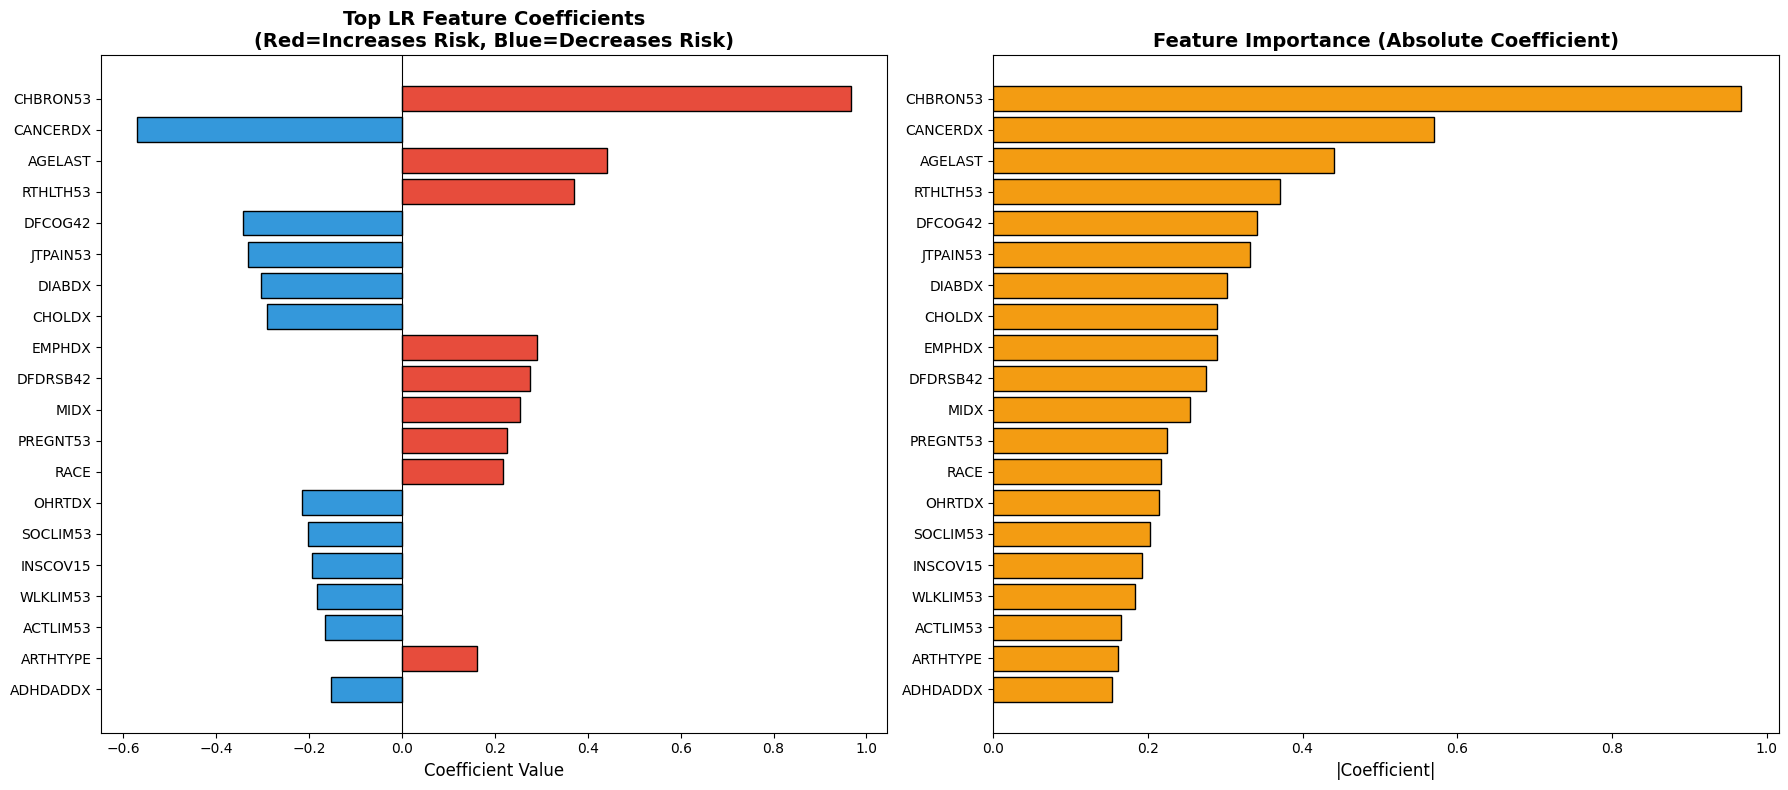


Top 10 most important features:
  CHBRON53         coef=+0.9669  (↑ High Util)
  CANCERDX         coef=-0.5705  (↓ Low Util)
  AGELAST          coef=+0.4409  (↑ High Util)
  RTHLTH53         coef=+0.3703  (↑ High Util)
  DFCOG42          coef=-0.3417  (↓ Low Util)
  JTPAIN53         coef=-0.3325  (↓ Low Util)
  DIABDX           coef=-0.3030  (↓ Low Util)
  CHOLDX           coef=-0.2900  (↓ Low Util)
  EMPHDX           coef=+0.2899  (↑ High Util)
  DFDRSB42         coef=+0.2757  (↑ High Util)


In [ ]:
# Extract LR coefficients (model is a pipeline: StandardScaler → LogisticRegression)
lr_model = lr_orig_panel19.named_steps['logisticregression']
coefficients = lr_model.coef_[0]

# Sort by absolute value
coef_df = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=True)

# Plot top 20 features
top_n = min(20, len(coef_df))
top_features = coef_df.tail(top_n)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Horizontal bar chart of coefficients
colors = ['#e74c3c' if c > 0 else '#3498db' for c in top_features['Coefficient']]
axes[0].barh(top_features['Feature'], top_features['Coefficient'], color=colors, edgecolor='black')
axes[0].set_xlabel('Coefficient Value', fontsize=12)
axes[0].set_title('Top LR Feature Coefficients\n(Red=Increases Risk, Blue=Decreases Risk)',
                   fontsize=14, fontweight='bold')
axes[0].axvline(0, color='black', linewidth=0.8)

# Absolute importance
axes[1].barh(top_features['Feature'], top_features['Abs_Coefficient'], color='#f39c12', edgecolor='black')
axes[1].set_xlabel('|Coefficient|', fontsize=12)
axes[1].set_title('Feature Importance (Absolute Coefficient)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print top 10
print("\nTop 10 most important features:")
for _, row in coef_df.tail(10).iloc[::-1].iterrows():
    direction = "↑ High Util" if row['Coefficient'] > 0 else "↓ Low Util"
    print(f"  {row['Feature']:15s}  coef={row['Coefficient']:+.4f}  ({direction})")

### 3.2.5 LIME Explanations for Logistic Regression Predictions

We use LIME (Local Interpretable Model-agnostic Explanations) to explain individual predictions made by the LR model. LIME perturbs the input features and observes how predictions change, building a local linear approximation that reveals which features drove the prediction for each sample.

=== LIME Explanation: Non-White individual ===
--- Instance 0 ---
  Actual label:    Low Util
  Predicted:       High Util (P(High)=0.497, threshold=0.180)
  Race:            Non-White


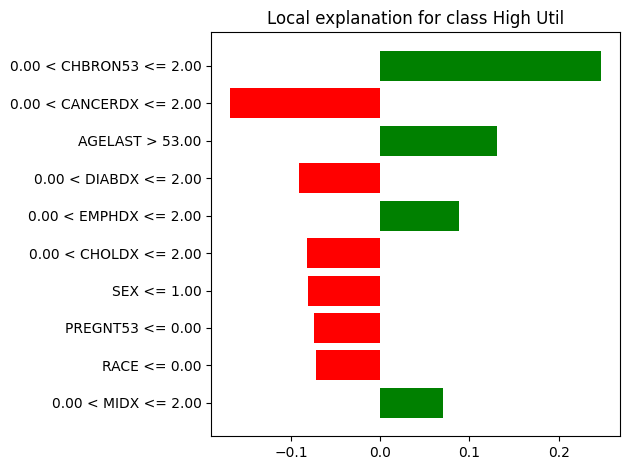


=== LIME Explanation: White individual ===
--- Instance 4 ---
  Actual label:    Low Util
  Predicted:       Low Util (P(High)=0.162, threshold=0.180)
  Race:            White


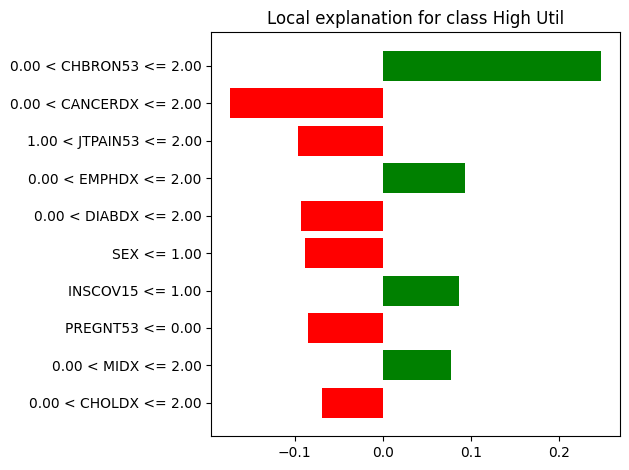


=== LIME Explanation: High Utilization case ===
--- Instance 12 ---
  Actual label:    High Util
  Predicted:       Low Util (P(High)=0.143, threshold=0.180)
  Race:            Non-White


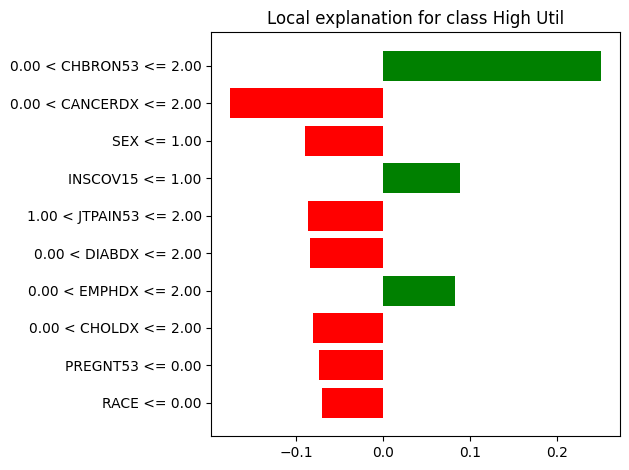

In [ ]:
# Create LIME explainer
explainer = LimeTabularExplainer(
    X_train,
    feature_names=feature_columns,
    class_names=['Low Util', 'High Util'],
    discretize_continuous=True,
    random_state=1
)

best_thresh = thresh_arr[lr_orig_best_ind]

def show_lime_explanation(idx, dataset_X, dataset_y, dataset_race):
    """Show LIME explanation for a single test instance."""
    exp = explainer.explain_instance(
        dataset_X[idx],
        lr_orig_panel19.predict_proba,
        num_features=10
    )
    pred_prob = lr_orig_panel19.predict_proba(dataset_X[idx].reshape(1, -1))[0]
    pred_label = int(pred_prob[1] > best_thresh)
    race_label = "White" if dataset_race[idx] == 1 else "Non-White"

    print(f"--- Instance {idx} ---")
    print(f"  Actual label:    {'High Util' if dataset_y[idx]==1 else 'Low Util'}")
    print(f"  Predicted:       {'High Util' if pred_label==1 else 'Low Util'} "
          f"(P(High)={pred_prob[1]:.3f}, threshold={best_thresh:.3f})")
    print(f"  Race:            {race_label}")
    exp.as_pyplot_figure()
    plt.tight_layout()
    plt.show()

# Explain a few test instances (one from each group)
nonwhite_indices = np.where(race_test == 0)[0]
white_indices = np.where(race_test == 1)[0]

print("=== LIME Explanation: Non-White individual ===")
show_lime_explanation(nonwhite_indices[0], X_test, y_test, race_test)

print("\n=== LIME Explanation: White individual ===")
show_lime_explanation(white_indices[0], X_test, y_test, race_test)

# Also explain a correctly predicted High-utilization case
high_util_idx = np.where(y_test == 1)[0]
if len(high_util_idx) > 0:
    print("\n=== LIME Explanation: High Utilization case ===")
    show_lime_explanation(high_util_idx[0], X_test, y_test, race_test)

### 3.2.6 Prediction Bias Detection via Signed Residuals

Following the approach from equalized coverage literature, we analyze **signed residuals** $R_i = Y_i - \hat{P}_i$ (where $\hat{P}_i$ is the predicted probability of high utilization) to detect prediction bias across racial groups.

If the model is fair, the empirical CDFs $\mathbb{P}\{R \leq r \mid A=0\}$ and $\mathbb{P}\{R \leq r \mid A=1\}$ should be approximately equal. Divergence between these CDFs indicates that the model systematically over- or under-predicts for one group relative to the other.

In [ ]:
# Compute signed residuals: Y - P(Y=1|X)
predictions_prob = lr_orig_panel19.predict_proba(X_test)[:, 1]
signed_residual = y_test.astype(float) - predictions_prob

# Split by race group
signed_residual_nonwhite = signed_residual[race_test == 0]
signed_residual_white = signed_residual[race_test == 1]

# Compute quantiles per group (alpha/2 and 1-alpha/2)
def compute_lo_hi_q(residuals, alpha):
    err_high = residuals.copy()
    err_low = -residuals.copy()
    combined = np.column_stack((err_low, err_high))
    combined = np.sort(combined, axis=0)
    index = int(np.ceil((1 - alpha / 2) * combined.shape[0])) - 1
    return -combined[index, 0], combined[index, 1]

lo_nw, up_nw = compute_lo_hi_q(signed_residual_nonwhite, alpha=0.1)
lo_w, up_w = compute_lo_hi_q(signed_residual_white, alpha=0.1)
med_nw = np.mean(signed_residual_nonwhite <= 0)
med_w = np.mean(signed_residual_white <= 0)

print("=== Signed Residual Analysis (R = Y - P(Y=1|X)) ===")
print(f"\nNon-White (A=0): median_cdf={med_nw:.3f}, lower_q={lo_nw:.3f}, upper_q={up_nw:.3f}")
print(f"White     (A=1): median_cdf={med_w:.3f}, lower_q={lo_w:.3f}, upper_q={up_w:.3f}")
print(f"\nP(Y ≤ Ŷ | Non-White) = {med_nw:.3f}")
print(f"P(Y ≤ Ŷ | White)     = {med_w:.3f}")
if med_nw > med_w:
    print("→ Model OVER-estimates utilization for Non-White and UNDER-estimates for White")
elif med_nw < med_w:
    print("→ Model UNDER-estimates utilization for Non-White and OVER-estimates for White")
else:
    print("→ Model predictions are approximately unbiased across groups")

=== Signed Residual Analysis (R = Y - P(Y=1|X)) ===

Non-White (A=0): median_cdf=0.873, lower_q=-0.335, upper_q=0.817
White     (A=1): median_cdf=0.736, lower_q=-0.568, upper_q=0.770

P(Y ≤ Ŷ | Non-White) = 0.873
P(Y ≤ Ŷ | White)     = 0.736
→ Model OVER-estimates utilization for Non-White and UNDER-estimates for White


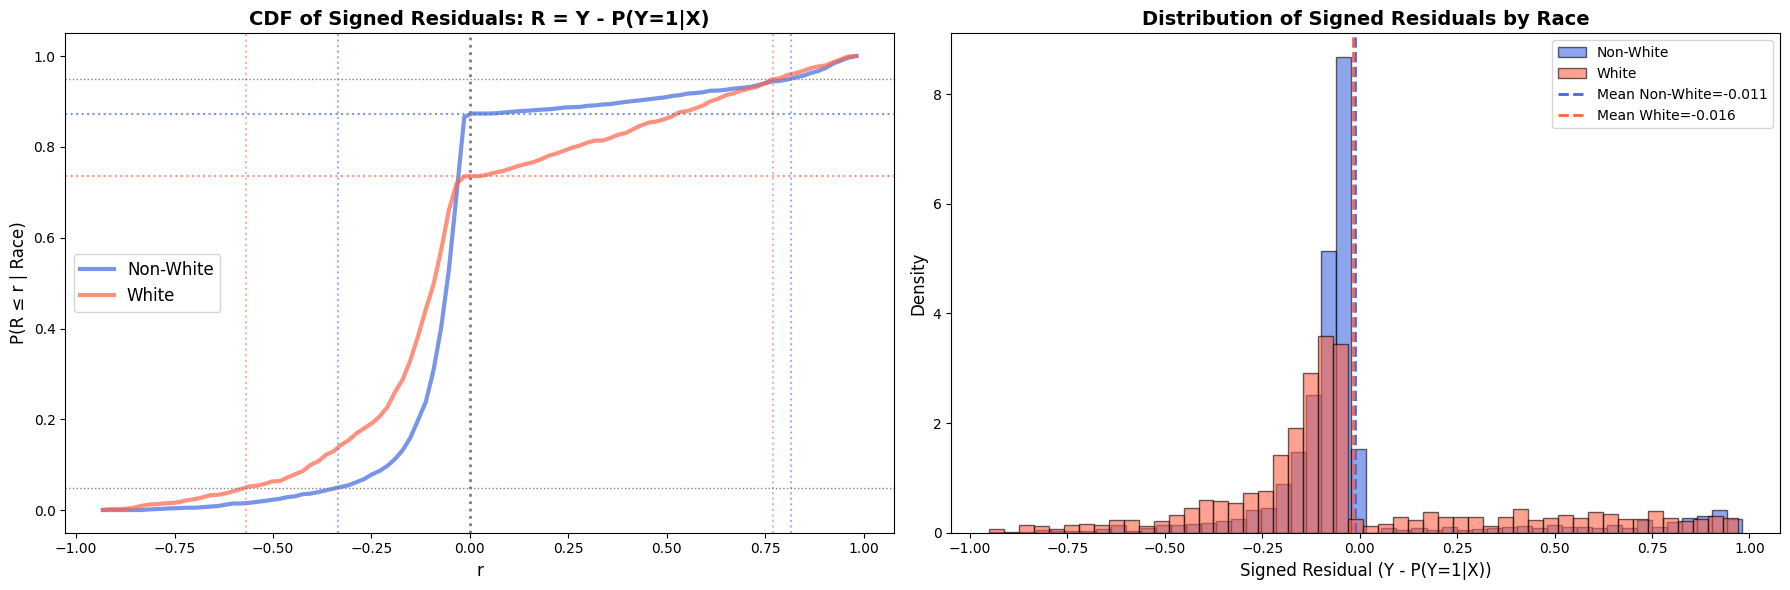


Kolmogorov-Smirnov test (H0: same distribution):
  KS statistic = 0.2048, p-value = 0.000000
  REJECT H0 → Distributions DIFFER (bias detected)


In [ ]:
# Plot CDFs of signed residuals by race (replicating Figure 1 from equalized coverage paper)
nbins = 100
bins = np.linspace(min(signed_residual), max(signed_residual), nbins)

counts_nw, bin_edges_nw = np.histogram(signed_residual_nonwhite, bins=bins, density=True)
cdf_nw = np.cumsum(counts_nw)

counts_w, bin_edges_w = np.histogram(signed_residual_white, bins=bins, density=True)
cdf_w = np.cumsum(counts_w)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# CDF plot
ax = axes[0]
ax.plot(bin_edges_nw[1:], cdf_nw / cdf_nw[-1], alpha=0.7, linewidth=3, label='Non-White', color='royalblue')
ax.plot(bin_edges_w[1:], cdf_w / cdf_w[-1], alpha=0.7, linewidth=3, label='White', color='tomato')
ax.axvline(0, color='gray', linestyle=':', linewidth=2)
ax.axhline(med_nw, color='royalblue', linestyle=':', linewidth=1.5, alpha=0.7)
ax.axhline(med_w, color='tomato', linestyle=':', linewidth=1.5, alpha=0.7)
ax.axvline(up_nw, color='royalblue', linestyle=':', linewidth=1.5, alpha=0.5)
ax.axvline(lo_nw, color='royalblue', linestyle=':', linewidth=1.5, alpha=0.5)
ax.axvline(up_w, color='tomato', linestyle=':', linewidth=1.5, alpha=0.5)
ax.axvline(lo_w, color='tomato', linestyle=':', linewidth=1.5, alpha=0.5)
ax.axhline(0.05, color='gray', linestyle=':', linewidth=1)
ax.axhline(0.95, color='gray', linestyle=':', linewidth=1)
ax.set_title('CDF of Signed Residuals: R = Y - P(Y=1|X)', fontsize=14, fontweight='bold')
ax.set_ylabel('P(R ≤ r | Race)', fontsize=12)
ax.set_xlabel('r', fontsize=12)
ax.legend(fontsize=12)

# Distribution of residuals by group
ax2 = axes[1]
ax2.hist(signed_residual_nonwhite, bins=50, alpha=0.6, color='royalblue', label='Non-White', density=True, edgecolor='black')
ax2.hist(signed_residual_white, bins=50, alpha=0.6, color='tomato', label='White', density=True, edgecolor='black')
ax2.axvline(np.mean(signed_residual_nonwhite), color='royalblue', linestyle='--', linewidth=2,
            label=f'Mean Non-White={np.mean(signed_residual_nonwhite):.3f}')
ax2.axvline(np.mean(signed_residual_white), color='tomato', linestyle='--', linewidth=2,
            label=f'Mean White={np.mean(signed_residual_white):.3f}')
ax2.set_title('Distribution of Signed Residuals by Race', fontsize=14, fontweight='bold')
ax2.set_xlabel('Signed Residual (Y - P(Y=1|X))', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Kolmogorov-Smirnov test for distribution equality
from scipy import stats
ks_stat, ks_pval = stats.ks_2samp(signed_residual_nonwhite, signed_residual_white)
print(f"\nKolmogorov-Smirnov test (H0: same distribution):")
print(f"  KS statistic = {ks_stat:.4f}, p-value = {ks_pval:.6f}")
print(f"  {'REJECT H0 → Distributions DIFFER (bias detected)' if ks_pval < 0.05 else 'FAIL TO REJECT H0 → No significant difference'}")

The CDF comparison reveals whether the model's prediction errors are distributed differently across racial groups. If the CDFs diverge significantly (confirmed by the KS test), the model exhibits **prediction bias** — it systematically over- or under-predicts for one group relative to the other. This motivates the need for bias mitigation techniques explored in subsequent sections.

---

### Summary: What We Did and What's Next

**Objective:** Build a healthcare utilization prediction model using the MEPS 2015 (HC-181) dataset and assess whether it exhibits racial bias.

**What we did:**
1. **Data Preparation** — Loaded the MEPS HC-181 survey data, constructed a binary "high utilization" label (≥10 visits), and defined the sensitive attribute RACE (White vs. Non-White). Selected 40 clinically relevant features covering demographics, diagnoses, limitations, and insurance status.

2. **Exploratory Data Analysis** — Visualized class imbalance (~17% high utilization), racial composition, diagnosis prevalence by race, age distributions, and feature correlations. Observed that certain conditions (e.g., diabetes, arthritis) have different prevalence rates across racial groups, which could propagate into model predictions.

3. **Logistic Regression Classifier** — Trained an LR model with sample weights, validated across classification thresholds to optimize balanced accuracy, and evaluated fairness metrics (disparate impact, average odds difference, statistical parity, equal opportunity, Theil index). The fairness metrics revealed that the model treats racial groups unequally.

4. **Feature Importance** — Analyzed LR coefficients to understand which features drive predictions most. This transparency helps identify whether the model relies on features correlated with the sensitive attribute.

5. **LIME Explanations** — Generated local explanations for individual predictions, showing which features contributed to classifying specific patients as high or low utilization. This is critical for clinical transparency and nurse review in care management workflows.

6. **Bias Detection via Signed Residuals** — Adapted the empirical CDF approach from equalized coverage research to compare prediction error distributions across racial groups. The Kolmogorov-Smirnov test quantifies whether prediction bias exists statistically.

**Key Concern:** The baseline logistic regression model, trained on original (unmodified) data, shows measurable unfairness across racial groups. Non-White and White populations receive systematically different prediction error distributions, indicating that care management decisions based on this model could perpetuate healthcare disparities.

**What we will improve (next sections):**
- **Reweighing (pre-processing)** — Adjust sample weights to equalize label distributions across groups before training
- **Prejudice Remover (in-processing)** — Incorporate a fairness regularizer directly into the learning objective
- **Model retraining and deployment monitoring** — Track fairness drift over time using newer panel data
- **Goal:** Achieve a model that is both accurate AND fair — maintaining balanced accuracy while bringing disparate impact closer to 1.0 and other fairness metrics closer to 0

### 3.3. Learning a Random Forest (RF) classifier on original data

#### 3.3.1. Training RF model on original data

In [ ]:
model = make_pipeline(StandardScaler(),
                      RandomForestClassifier(n_estimators=500, min_samples_leaf=25))
fit_params = {'randomforestclassifier__sample_weight': w_train}
rf_orig_panel19 = model.fit(X_train, y_train, **fit_params)

#### 3.3.2. Validating RF model on original data

In [ ]:
thresh_arr = np.linspace(0.01, 0.5, 50)
val_metrics = test(X=X_val, y=y_val, race=race_val,
                   model=rf_orig_panel19,
                   thresh_arr=thresh_arr)
rf_orig_best_ind = np.argmax(val_metrics['bal_acc'])

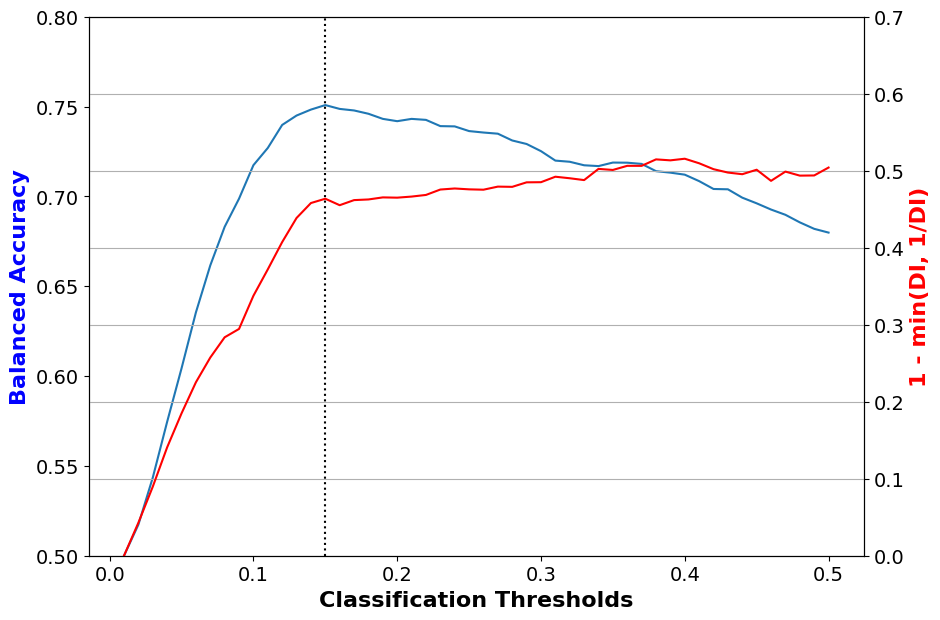

In [ ]:
disp_imp = np.array(val_metrics['disp_imp'])
disp_imp_err = 1 - np.minimum(disp_imp, 1/disp_imp)
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     disp_imp_err, '1 - min(DI, 1/DI)')

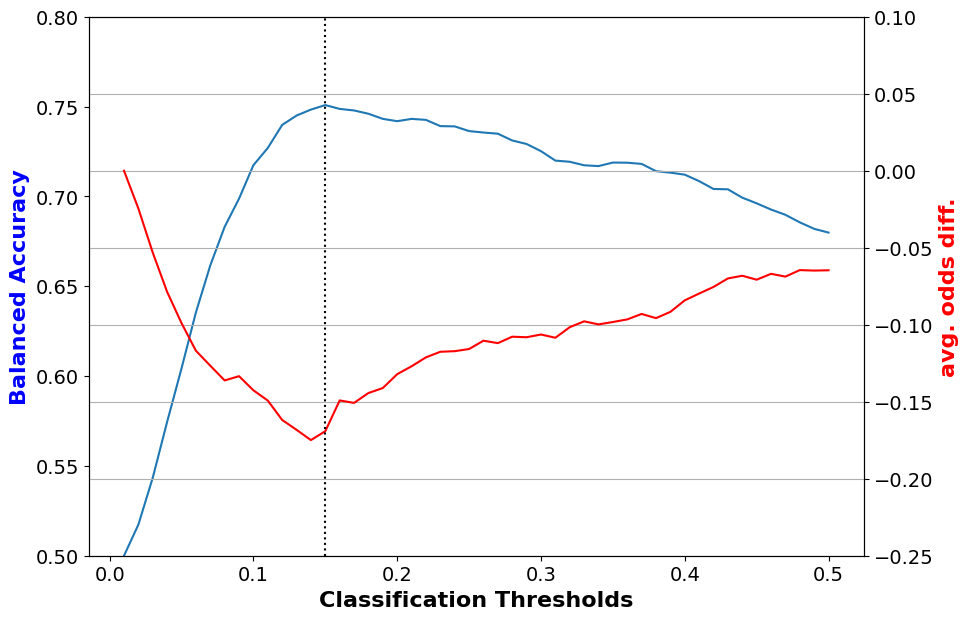

In [ ]:
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     val_metrics['avg_odds_diff'], 'avg. odds diff.')

In [ ]:
describe_metrics(val_metrics, thresh_arr)

Threshold corresponding to Best balanced accuracy: 0.1500
Best balanced accuracy: 0.7508
Corresponding 1-min(DI, 1/DI) value: 0.4636
Corresponding average odds difference value: -0.1691
Corresponding statistical parity difference value: -0.2645
Corresponding equal opportunity difference value: -0.1039
Corresponding Theil index value: 0.0884


#### 3.3.3. Testing RF model on original data

In [ ]:
rf_orig_metrics = test(X=X_test, y=y_test, race=race_test,
                       model=rf_orig_panel19,
                       thresh_arr=[thresh_arr[rf_orig_best_ind]])

In [ ]:
describe_metrics(rf_orig_metrics, [thresh_arr[rf_orig_best_ind]])

Threshold corresponding to Best balanced accuracy: 0.1500
Best balanced accuracy: 0.7536
Corresponding 1-min(DI, 1/DI) value: 0.4701
Corresponding average odds difference value: -0.1930
Corresponding statistical parity difference value: -0.2706
Corresponding equal opportunity difference value: -0.1700
Corresponding Theil index value: 0.0876


As in the case of the logistic regression classifier learned on the original data, the fairness metrics for the random forest classifier have values that are quite far from 0.

For example, 1 - min(DI, 1/DI) has a value of over 0.5 as opposed to the desired value of < 0.2.

This indicates that the random forest classifier learned on the original data is also unfair.

## [4.](#Table-of-Contents) Bias mitigation using pre-processing technique - Reweighing

### 4.1. Transform data

In [ ]:
RW = Reweighing(unprivileged_groups=unprivileged_groups,
                privileged_groups=privileged_groups)
dataset_transf_panel19_train = RW.fit_transform(dataset_orig_panel19_train)

Metrics for transformed data

In [ ]:
metric_transf_panel19_train = BinaryLabelDatasetMetric(
        dataset_transf_panel19_train,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups)

print(metric_transf_panel19_train.disparate_impact())

1.0000000000000002


### 4.2. Learning a Logistic Regression (LR) classifier on data transformed by reweighing

#### 4.2.1. Training LR model after reweighing

In [ ]:
dataset = dataset_transf_panel19_train
model = make_pipeline(StandardScaler(),
                      LogisticRegression(solver='liblinear', random_state=1))
fit_params = {'logisticregression__sample_weight': dataset.instance_weights}
lr_transf_panel19 = model.fit(dataset.features, dataset.labels.ravel(), **fit_params)

#### 4.2.2. Validating  LR model after reweighing

In [ ]:
thresh_arr = np.linspace(0.01, 0.5, 50)
val_metrics = test(X=dataset_orig_panel19_val.features,
                   y=dataset_orig_panel19_val.labels.ravel(),
                   race=race_val,
                   model=lr_transf_panel19,
                   thresh_arr=thresh_arr)
lr_transf_best_ind = np.argmax(val_metrics['bal_acc'])

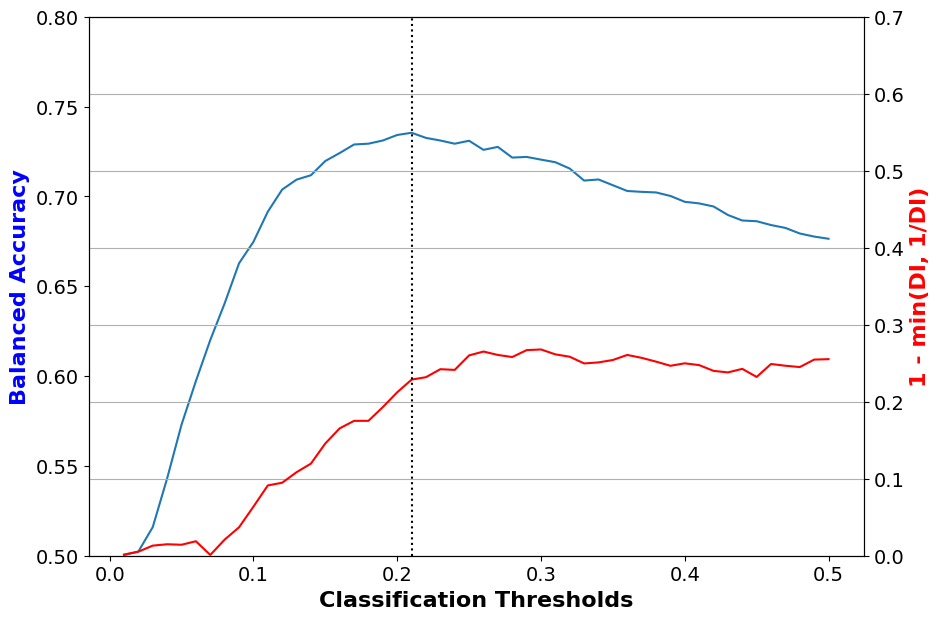

In [ ]:
disp_imp = np.array(val_metrics['disp_imp'])
disp_imp_err = 1 - np.minimum(disp_imp, 1/disp_imp)
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     disp_imp_err, '1 - min(DI, 1/DI)')

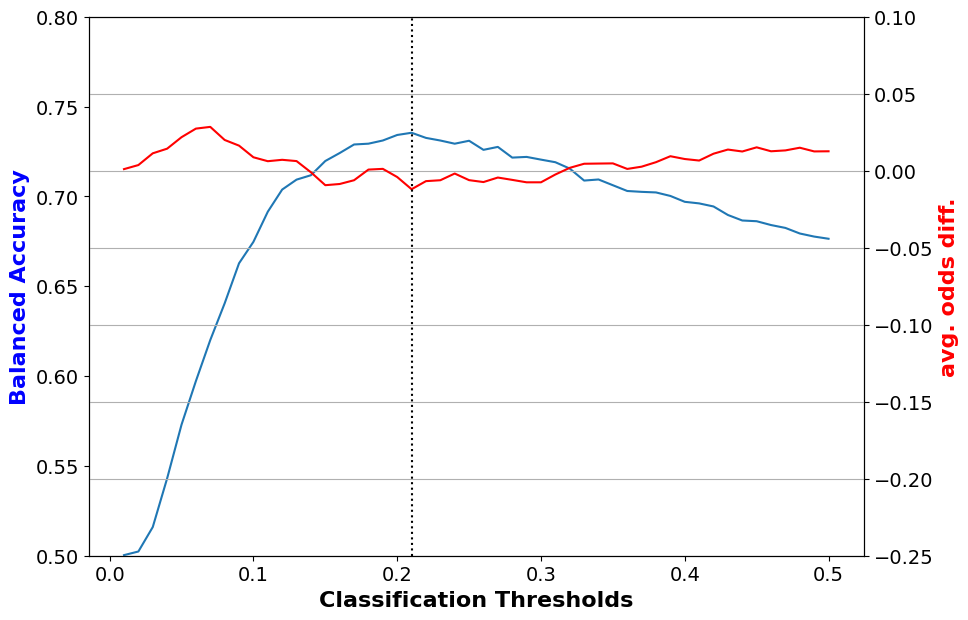

In [ ]:
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     val_metrics['avg_odds_diff'], 'avg. odds diff.')

In [ ]:
describe_metrics(val_metrics, thresh_arr)

Threshold corresponding to Best balanced accuracy: 0.2100
Best balanced accuracy: 0.7354
Corresponding 1-min(DI, 1/DI) value: 0.2287
Corresponding average odds difference value: -0.0120
Corresponding statistical parity difference value: -0.0825
Corresponding equal opportunity difference value: 0.0116
Corresponding Theil index value: 0.1028


#### 4.2.3. Testing  LR model after reweighing

In [ ]:
lr_transf_metrics = test(X=X_test, y=y_test, race=race_test,
                         model=lr_transf_panel19,
                         thresh_arr=[thresh_arr[lr_transf_best_ind]])

In [ ]:
describe_metrics(lr_transf_metrics, [thresh_arr[lr_transf_best_ind]])

Threshold corresponding to Best balanced accuracy: 0.2100
Best balanced accuracy: 0.7512
Corresponding 1-min(DI, 1/DI) value: 0.2753
Corresponding average odds difference value: -0.0467
Corresponding statistical parity difference value: -0.1051
Corresponding equal opportunity difference value: -0.0629
Corresponding Theil index value: 0.0968


The fairness metrics for the logistic regression model learned after reweighing are well improved, and thus the model is much more fair relative to the logistic regression model learned from the original data.

### 4.3. Learning a Random Forest (RF) classifier on data transformed by reweighing

#### 4.3.1. Training  RF model after reweighing

In [ ]:
dataset = dataset_transf_panel19_train
model = make_pipeline(StandardScaler(),
                      RandomForestClassifier(n_estimators=500, min_samples_leaf=25))
fit_params = {'randomforestclassifier__sample_weight': dataset.instance_weights}
rf_transf_panel19 = model.fit(dataset.features, dataset.labels.ravel(), **fit_params)

#### 4.3.2. Validating  RF model after reweighing

In [ ]:
thresh_arr = np.linspace(0.01, 0.5, 50)
val_metrics = test(X=dataset_orig_panel19_val.features,
                   y=dataset_orig_panel19_val.labels.ravel(),
                   race=race_val,
                   model=rf_transf_panel19,
                   thresh_arr=thresh_arr)
rf_transf_best_ind = np.argmax(val_metrics['bal_acc'])

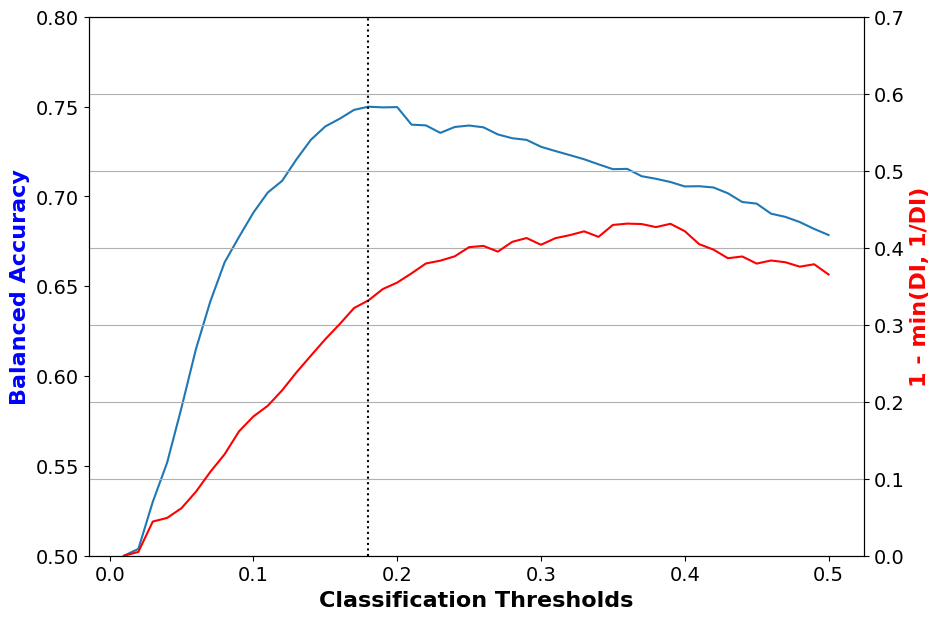

In [ ]:
disp_imp = np.array(val_metrics['disp_imp'])
disp_imp_err = 1 - np.minimum(disp_imp, 1/disp_imp)
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     disp_imp_err, '1 - min(DI, 1/DI)')

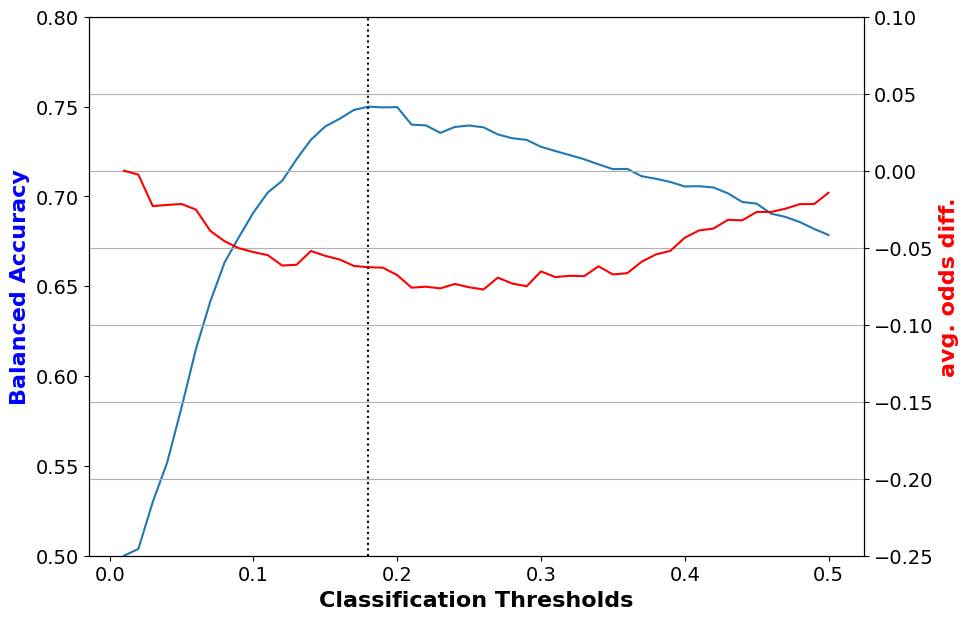

In [ ]:
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     val_metrics['avg_odds_diff'], 'avg. odds diff.')

In [ ]:
describe_metrics(val_metrics, thresh_arr)

Threshold corresponding to Best balanced accuracy: 0.1800
Best balanced accuracy: 0.7499
Corresponding 1-min(DI, 1/DI) value: 0.3316
Corresponding average odds difference value: -0.0626
Corresponding statistical parity difference value: -0.1534
Corresponding equal opportunity difference value: -0.0090
Corresponding Theil index value: 0.0928


#### 4.3.3. Testing  RF model after reweighing

In [ ]:
rf_transf_metrics = test(X=dataset_orig_panel19_test.features,
                         y=dataset_orig_panel19_test.labels.ravel(),
                         race=race_test,
                         model=rf_transf_panel19,
                         thresh_arr=[thresh_arr[rf_transf_best_ind]])

In [ ]:
describe_metrics(rf_transf_metrics, [thresh_arr[rf_transf_best_ind]])

Threshold corresponding to Best balanced accuracy: 0.1800
Best balanced accuracy: 0.7591
Corresponding 1-min(DI, 1/DI) value: 0.3601
Corresponding average odds difference value: -0.0976
Corresponding statistical parity difference value: -0.1702
Corresponding equal opportunity difference value: -0.0907
Corresponding Theil index value: 0.0899


Once again, the model learned from the transformed data is fairer than that learned from the original data. However, the random forest model learned from the transformed data is still relatively unfair as compared to the logistic regression model learned from the transformed data.

## [5.](#Table-of-Contents) Bias mitigation using in-processing technique - Prejudice Remover (PR)

### 5.1. Learning a Prejudice Remover (PR) model on original data

#### 5.1.1. Training a PR model

In [ ]:
model = PrejudiceRemover(sensitive_attr=sens_attr, eta=25.0)
pr_orig_scaler = StandardScaler()

dataset = dataset_orig_panel19_train.copy()
dataset.features = pr_orig_scaler.fit_transform(dataset.features)

pr_orig_panel19 = model.fit(dataset)

#### 5.1.2. Validating PR model

In [ ]:
thresh_arr = np.linspace(0.01, 0.50, 50)

dataset = dataset_orig_panel19_val.copy()
dataset.features = pr_orig_scaler.transform(dataset.features)

val_metrics = test(X=dataset.features,
                   y=dataset.labels.ravel(),
                   race=race_val,
                   model=pr_orig_panel19,
                   thresh_arr=thresh_arr)
pr_orig_best_ind = np.argmax(val_metrics['bal_acc'])

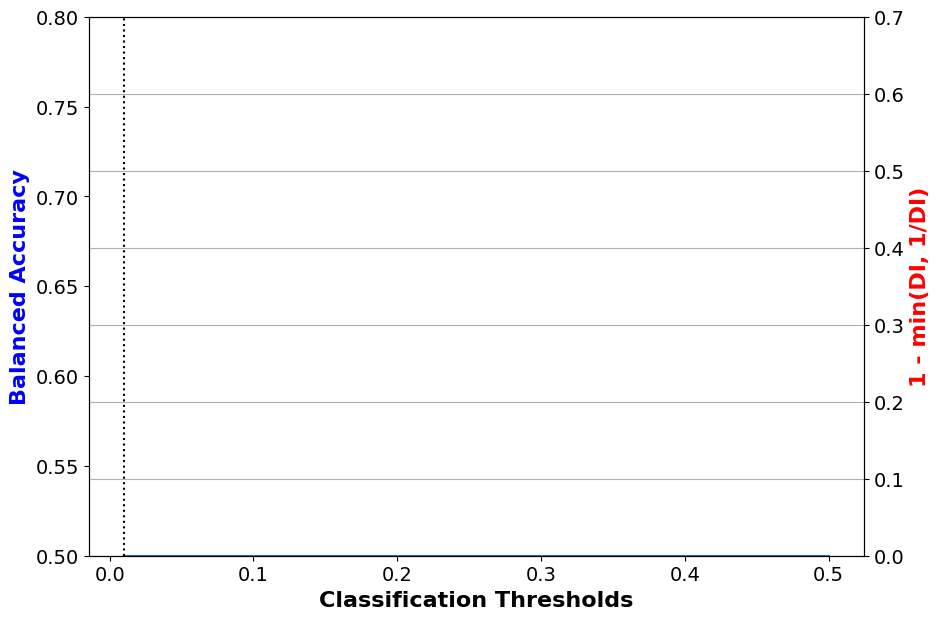

In [ ]:
disp_imp = np.array(val_metrics['disp_imp'])
disp_imp_err = 1 - np.minimum(disp_imp, 1/disp_imp)
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     disp_imp_err, '1 - min(DI, 1/DI)')

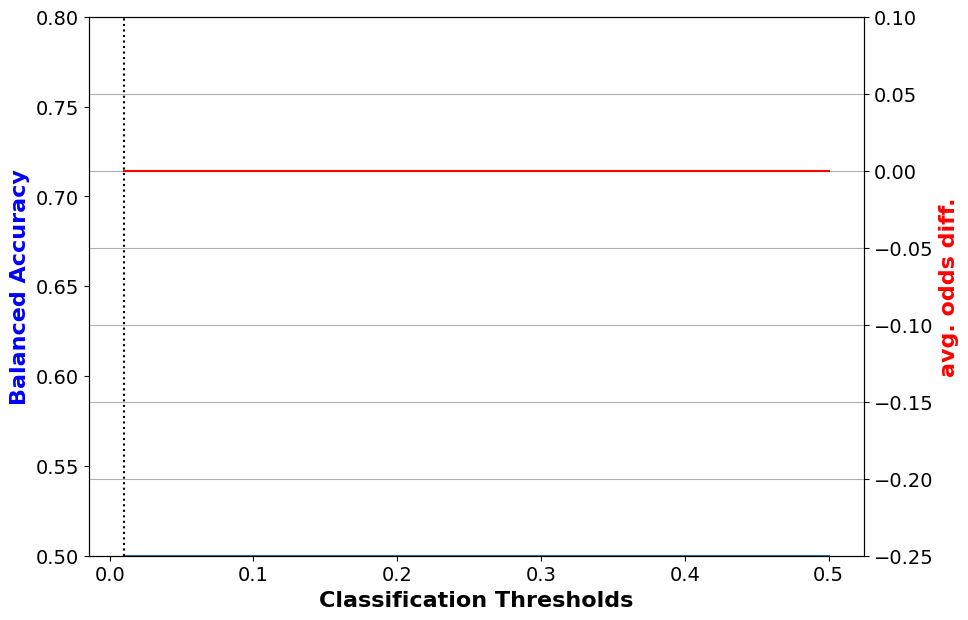

In [ ]:
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     val_metrics['avg_odds_diff'], 'avg. odds diff.')

In [ ]:
describe_metrics(val_metrics, thresh_arr)

Threshold corresponding to Best balanced accuracy: 0.0100
Best balanced accuracy: 0.5000
Corresponding 1-min(DI, 1/DI) value: 1.0000
Corresponding average odds difference value: 0.0000
Corresponding statistical parity difference value: 0.0000
Corresponding equal opportunity difference value: 0.0000
Corresponding Theil index value: 0.1921


#### 5.1.3. Testing PR model

In [ ]:
dataset = dataset_orig_panel19_test.copy()
dataset.features = pr_orig_scaler.transform(dataset.features)

pr_orig_metrics = test(X=dataset.features,
                       y=dataset.labels.ravel(),
                       race=race_test,
                       model=pr_orig_panel19,
                       thresh_arr=[thresh_arr[pr_orig_best_ind]])

In [ ]:
describe_metrics(pr_orig_metrics, [thresh_arr[pr_orig_best_ind]])

Threshold corresponding to Best balanced accuracy: 0.0100
Best balanced accuracy: 0.5000
Corresponding 1-min(DI, 1/DI) value: 1.0000
Corresponding average odds difference value: 0.0000
Corresponding statistical parity difference value: 0.0000
Corresponding equal opportunity difference value: 0.0000
Corresponding Theil index value: 0.1920


As in the case of reweighing, prejudice remover results in a fair model. However, it has come at the expense of relatively lower balanced accuracy.

## [6.](#Table-of-Contents) Summary of Model Learning Results

In [ ]:
import pandas as pd
pd.set_option('display.multi_sparse', False)
results = [lr_orig_metrics, rf_orig_metrics, lr_transf_metrics,
           rf_transf_metrics, pr_orig_metrics]
debias = pd.Series(['']*2 + ['Reweighing']*2
                 + ['Prejudice Remover'],
                   name='Bias Mitigator')
clf = pd.Series(['Logistic Regression', 'Random Forest']*2 + [''],
                name='Classifier')
pd.concat([pd.DataFrame(metrics) for metrics in results], axis=0).set_index([debias, clf])

,,bal_acc,avg_odds_diff,disp_imp,stat_par_diff,eq_opp_diff,theil_ind
Bias Mitigator,Classifier,,,,,,
,Logistic Regression,0.764009,-0.236845,0.402612,-0.299403,-0.242193,0.092795
,Random Forest,0.753575,-0.192986,0.529891,-0.270601,-0.170016,0.087647
Reweighing,Logistic Regression,0.751194,-0.046701,0.724654,-0.105080,-0.062854,0.096838
Reweighing,Random Forest,0.759100,-0.097646,0.639886,-0.170220,-0.090725,0.089930
Prejudice Remover,,0.500000,0.000000,0.000000,0.000000,0.000000,0.192045


Of all the models, the logistic regression model gives the best balance in terms of balanced accuracy and fairness. While the model learnt by prejudice remover is slightly fairer, it has much lower accuracy. All other models are quite unfair compared to the logistic model. Hence, we take the logistic regression model learnt from data transformed by re-weighing and 'deploy' it.

## [7.](#Table-of-Contents) Deploying model

### 7.1. Testing model learned on 2014 (Panel 19) on 2015 (Panel 20) deployment data

In [ ]:
# Instead of using MEPSDataset20(), manually construct the dataset for Panel 20 deployment
# Use the global 'df' dataframe (loaded from h181.csv)

# Filter original dataframe for Panel 20 (assuming 'RND' column might not exist or is consolidated)
df_panel20_deploy_raw = df.loc[df['PANEL'] == 20].copy()

# Apply the same feature selection and target/sensitive attribute creation logic as earlier
# (RACE and LABEL columns are already present in df_panel20_deploy_raw after initial preprocessing)
df_model_panel20_deploy = df_panel20_deploy_raw[feature_columns + ['LABEL', 'PERWT15F']].dropna().copy()

X_panel20_deploy = df_model_panel20_deploy[feature_columns].values
y_panel20_deploy = df_model_panel20_deploy['LABEL'].values
race_panel20_deploy = df_model_panel20_deploy['RACE'].values
w_panel20_deploy = df_model_panel20_deploy['PERWT15F'].values

# Create AIF360 BinaryLabelDataset object for Panel 20 deployment
dataset_orig_panel20_deploy = create_aif_dataset(
    X_panel20_deploy, y_panel20_deploy, race_panel20_deploy, w_panel20_deploy,
    feature_columns, sens_attr, privileged_groups, unprivileged_groups, "Panel 20 Deploy"
)

# Align it with the training dataset for consistency (e.g., feature order)
dataset_orig_panel20_deploy = dataset_orig_panel19_train.align_datasets(dataset_orig_panel20_deploy)

Created Panel 20 Deploy AIF360 dataset with shape: (1504, 40)


In [ ]:
# describe(dataset_orig_panel20_train, dataset_orig_panel20_val, dataset_orig_panel20_deploy)
describe(X_train=np.empty((0, dataset_orig_panel19_train.features.shape[1])),
         y_train=np.empty((0,)),
         X_val=np.empty((0, dataset_orig_panel19_train.features.shape[1])),
         y_val=np.empty((0,)),
         X_test=dataset_orig_panel20_deploy.features,
         y_test=dataset_orig_panel20_deploy.labels.ravel(),
         feature_columns=feature_columns)

#### Training Dataset shape

(0, 40)


#### Validation Dataset shape

(0, 40)


#### Test Dataset shape

...

RACE: White=1 (privileged), Non-White=0 (unprivileged)


#### Label distribution

  Train: nan positive rate (0/0)
  Val: nan positive rate (0/0)
  Test: 0.176 positive rate (264/1504)


#### Feature names

['AGELAST', 'SEX', 'RACE', 'MARRY15X', 'EDUCYR', 'FTSTU53X', 'ACTDTY53', 'HONRDC53', 'RTHLTH53', 'MNHLTH53', 'HIBPDX', 'CHDDX', 'ANGIDX', 'MIDX', 'OHRTDX', 'STRKDX', 'EMPHDX', 'CHBRON53', 'CHOLDX', 'CANCERDX', 'DIABDX', 'JTPAIN53', 'ARTHDX', 'ARTHTYPE', 'ASTHDX', 'ADHDADDX', 'PREGNT53', 'WLKLIM53', 'ACTLIM53', 'SOCLIM53', 'COGLIM53', 'DFHEAR42', 'DFSEE42', 'DFCOG42', 'DFWLKC42', 'DFDRSB42', 'DFERND42', 'INSCOV15', 'POVCAT15', 'REGION15']


In [ ]:
metric_orig_panel20_deploy = BinaryLabelDatasetMetric(
        dataset_orig_panel20_deploy,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups)

print(metric_orig_panel20_deploy.disparate_impact())

0.6305688151020397


In [ ]:
lr_transf_metrics_panel20_deploy = test(
        X=dataset_orig_panel20_deploy.features,
        y=dataset_orig_panel20_deploy.labels.ravel(),
        race=race_panel20_deploy,
        model=lr_transf_panel19,
        thresh_arr=[thresh_arr[lr_transf_best_ind]])

In [ ]:
describe_metrics(lr_transf_metrics_panel20_deploy, [thresh_arr[lr_transf_best_ind]])

Threshold corresponding to Best balanced accuracy: 0.2100
Best balanced accuracy: 0.7466
Corresponding 1-min(DI, 1/DI) value: 0.3006
Corresponding average odds difference value: -0.0350
Corresponding statistical parity difference value: -0.1079
Corresponding equal opportunity difference value: -0.0054
Corresponding Theil index value: 0.1005


Deployed model tested on the 2015 Panel 20 data still exhibits fairness as well as maintains accuracy.

## [8.](#Table-of-Contents) Generating explanations for model predictions using LIME

### 8.1. Generating explanations on 2015 Panel 20 deployment data

This section shows how LIME can be integrated with AIF360 to get explanations for model predictions.

In [ ]:
train_dataset = dataset_transf_panel19_train  # data the deployed model (lr from transformed data)
test_dataset = dataset_orig_panel20_deploy  # the data model is being tested on
model = lr_transf_panel19  # lr_transf_panel19 is LR model learned from Panel 19 with Reweighing
thresh_arr = np.linspace(0.01, 0.5, 50)
best_thresh = thresh_arr[lr_transf_best_ind]

First, we need to fit the encoder to the aif360 dataset

In [ ]:
lime_data = LimeTabularExplainer(training_data=train_dataset.features, feature_names=feature_columns, class_names=['Low Util', 'High Util'])

The `transform()` method is then used to convert aif360 features to LIME-compatible features

The `LimeTabularExplainer` takes as input the LIME-compatible data along with various other arguments to create a lime explainer

In [ ]:
explainer = lime_data

The `inverse_transform()` function is used to transform LIME-compatible data back to aif360-compatible data since that is needed by the model to make predictions. The function below is used to produce the predictions for any perturbed data that is produce by LIME

In [ ]:
def s_predict_fn(x):
    return model.predict_proba(x)

The `explain_instance()` method can then be used to produce explanations for any instance in the test dataset

In [ ]:
def show_explanation(ind):
    exp = explainer.explain_instance(test_dataset.features[ind], s_predict_fn, num_features=10)
    print("Actual label: " + str(test_dataset.labels[ind]))
    exp.as_pyplot_figure()
    plt.show()

Threshold corresponding to Best balanced accuracy: 0.2100
Actual label: [0.]


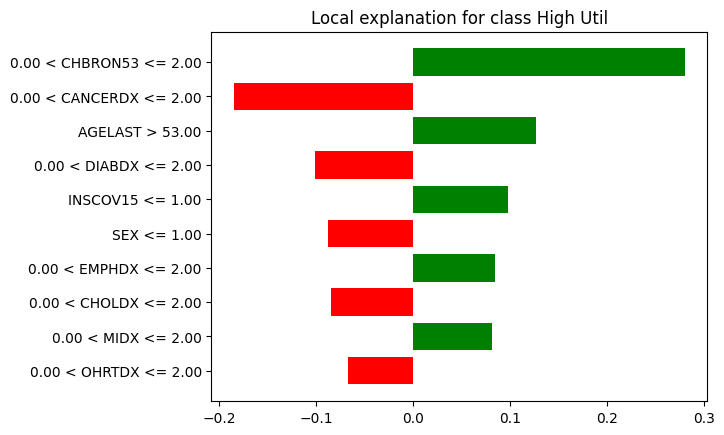

Actual label: [0.]


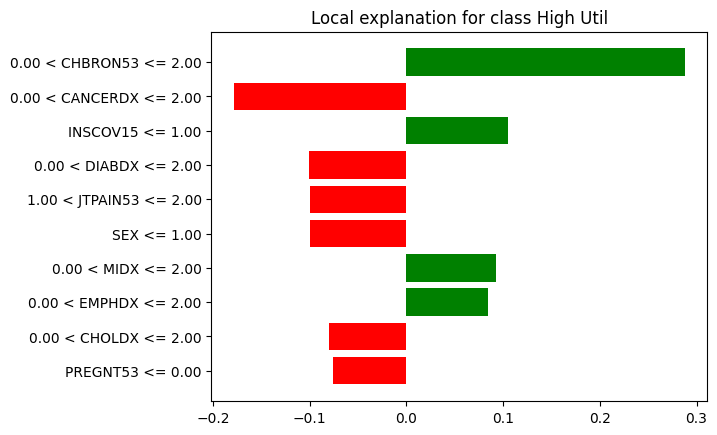

In [ ]:
print("Threshold corresponding to Best balanced accuracy: {:6.4f}".format(best_thresh))
show_explanation(0)
show_explanation(2)

See the [LIME documentation](https://github.com/marcotcr/lime) for detailed description of results. In short, the left hand side shows the label predictions made by the model, the middle shows the features that are important to the instance in question and their contributions (weights) to the label prediction, while the right hand side shows the actual values of the features in the particular instance.

## [9.](#Table-of-Contents) Re-deploying Model

### 9.1. Testing model learned on 2014 (Panel 19) data on 2016 (Panel 21) deployment data

Load the Panel 21 data, and split it again into 3 parts: train, validate, and deploy. We test the deployed model against the deployment data. If a new model needs to be learnt, it will be learnt from the train/validate data and then tested again on the deployment data.

In [ ]:
dataset_orig_panel21_deploy = MEPSDataset21()

# now align it with the panel19 datasets
dataset_orig_panel21_deploy = dataset_orig_panel19_train.align_datasets(dataset_orig_panel21_deploy)

describe(test=dataset_orig_panel21_deploy)

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



IOError: [Errno 2] No such file or directory: '/usr/local/lib/python3.12/dist-packages/aif360/datasets/../data/raw/meps/h192.csv'
To use this class, please follow the instructions in:

	/usr/local/lib/python3.12/dist-packages/aif360/data/raw/meps/README.md


 to download and convert the 2016 data and place the final h192.csv file, as-is, in the folder:

	/usr/local/lib/python3.12/dist-packages/aif360/data/raw/meps

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/aif360/datasets/meps_dataset_panel21_fy2016.py", line 95, in __init__
    df = pd.read_csv(filepath, sep=',', na_values=na_values)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 620, in _read
    parser = TextFil

TypeError: object of type 'NoneType' has no len()

In [ ]:
metric_orig_panel21_deploy = BinaryLabelDatasetMetric(
        dataset_orig_panel21_deploy,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups)
explainer_orig_panel21_deploy = MetricTextExplainer(metric_orig_panel21_deploy)

print(explainer_orig_panel21_deploy.disparate_impact())

Now, the logistic regression classifier trained on the panel 19 data after reweighing is tested against the panel 21 deployment data.

In [ ]:
lr_transf_metrics_panel21_deploy = test(
        dataset=dataset_orig_panel21_deploy,
        model=lr_transf_panel19,
        thresh_arr=[thresh_arr[lr_transf_best_ind]])

In [ ]:
describe_metrics(lr_transf_metrics_panel21_deploy, [thresh_arr[lr_transf_best_ind]])

Compared to the 2015 panel 20 deployment data results, the $|1 - \text{disparate impact}|$ fairness metric shows a noticable drift upwards. While still within specs, it may be worthwhile to re-learn the model. So even though the model is still relatively fair and accurate, we go ahead and re-learn the model from the 2015 Panel 20 data.

### 9.2. Re-learning model (from 2015 Panel 20 data)

In [ ]:
(dataset_orig_panel20_train,
 dataset_orig_panel20_val,
 dataset_orig_panel20_test) = MEPSDataset20().split([0.5, 0.8], shuffle=True)

# now align them with the 2014 datasets
dataset_orig_panel20_train = dataset_orig_panel19_train.align_datasets(dataset_orig_panel20_train)
dataset_orig_panel20_val = dataset_orig_panel19_train.align_datasets(dataset_orig_panel20_val)
dataset_orig_panel20_test = dataset_orig_panel19_train.align_datasets(dataset_orig_panel20_test)

**Train and evaluate  new model on 'transformed' 2016 training/test data**

In [ ]:
RW = Reweighing(unprivileged_groups=unprivileged_groups,
                privileged_groups=privileged_groups)
RW.fit(dataset_orig_panel20_train)
dataset_transf_panel20_train = RW.transform(dataset_orig_panel20_train)

In [ ]:
metric_transf_panel20_train = BinaryLabelDatasetMetric(
        dataset_transf_panel20_train,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups)
explainer_transf_panel20_train = MetricTextExplainer(metric_transf_panel20_train)

print(explainer_transf_panel20_train.disparate_impact())

In [ ]:
dataset = dataset_transf_panel20_train
model = make_pipeline(StandardScaler(),
                      LogisticRegression(solver='liblinear', random_state=1))
fit_params = {'logisticregression__sample_weight': dataset.instance_weights}
lr_transf_panel20 = model.fit(dataset.features, dataset.labels.ravel(), **fit_params)

In [ ]:
thresh_arr = np.linspace(0.01, 0.5, 50)
val_metrics = test(dataset=dataset_orig_panel20_val,
                   model=lr_transf_panel20,
                   thresh_arr=thresh_arr)
lr_transf_best_ind_panel20 = np.argmax(val_metrics['bal_acc'])

In [ ]:
disp_imp = np.array(val_metrics['disp_imp'])
disp_imp_err = 1 - np.minimum(disp_imp, 1/disp_imp)
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     disp_imp_err, '1 - min(DI, 1/DI)')

In [ ]:
plot(thresh_arr, 'Classification Thresholds',
     val_metrics['bal_acc'], 'Balanced Accuracy',
     val_metrics['avg_odds_diff'], 'avg. odds diff.')

In [ ]:
describe_metrics(val_metrics, thresh_arr)

In [ ]:
lr_transf_metrics_panel20_test = test(
        dataset=dataset_orig_panel20_test,
        model=lr_transf_panel20,
        thresh_arr=[thresh_arr[lr_transf_best_ind_panel20]])

In [ ]:
describe_metrics(lr_transf_metrics_panel20_test, [thresh_arr[lr_transf_best_ind_panel20]])

The new model is both relatively fair as well as accurate so we deploy and test against the 2016 deployment data

### 9.3. Testing model learned on 2015 (Panel 20) data on 2016 (Panel 21) deployment data

**Evaluate new 2015 transformed data model and evaluate again on 2016 deployment data**

In [ ]:
lr_transf_panel20_metrics_panel21_deploy = test(
        dataset=dataset_orig_panel21_deploy,
        model=lr_transf_panel20,
        thresh_arr=[thresh_arr[lr_transf_best_ind_panel20]])

In [ ]:
describe_metrics(lr_transf_panel20_metrics_panel21_deploy, [thresh_arr[lr_transf_best_ind_panel20]])

The new transformed 2016 data model is again within original accuracy/fairness specs so is deployed

## [10.](#Table-of-Contents) SUMMARY

In [ ]:
results = [lr_orig_metrics, lr_transf_metrics,
           lr_transf_metrics_panel20_deploy,
           lr_transf_metrics_panel21_deploy,
           lr_transf_metrics_panel20_test,
           lr_transf_panel20_metrics_panel21_deploy]
debias = pd.Series([''] + ['Reweighing']*5, name='Bias Mitigator')
clf = pd.Series(['Logistic Regression']*6, name='Classifier')
tr = pd.Series(['Panel19']*4 + ['Panel20']*2, name='Training set')
te = pd.Series(['Panel19']*2 + ['Panel20', 'Panel21']*2, name='Testing set')
pd.concat([pd.DataFrame(m) for m in results], axis=0).set_index([debias, clf, tr, te])